In [1]:
%load_ext autoreload
%autoreload 2

from spyglass.decoding.v1.clusterless import UnitWaveformFeaturesGroup, UnitWaveformFeatures
import matplotlib.pyplot as plt
from pynwb import TimeSeries
from pynwb import NWBHDF5IO
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax
os.chdir("/home/sambray/Documents/c3po")

from src.c3po.analysis.analysis import bootstrap_traces

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(
[2026-07-07 10:45:59,441][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


# Load Data

### Waveforms

In [2]:
key = {
    "nwb_file_name": "Wallie20220912_.nwb",
    "waveform_features_group_name": "10_lineartrack",
}


# waveform_keys = (UnitWaveformFeaturesGroup().UnitFeatures & key).fetch("KEY")
# times_list, marks_list = (UnitWaveformFeatures & waveform_keys).fetch_data()
# mark_times = []
# marks = []

# n_shanks = len(times_list)

# for shank, (t, m) in enumerate(zip(times_list, marks_list)):
#     mark_times.extend(t)
#     # mark = np.zeros((len(t),m.shape[1],n_shanks))
#     # mark[:, :, shank] = m
#     # marks.extend(mark)
#     mark = np.zeros((len(t), 4 + 1))
#     mark[:, : m.shape[1]] = m
#     mark[:, -1] = shank
#     marks.extend(mark)


# marks = np.array(marks)
# mark_times = np.array(mark_times)
# print(marks.shape, mark_times.shape)

# ind = np.argsort(mark_times)
# mark_times = mark_times[ind]
# marks = marks[ind]

# # standardize marks
# marks[:, :-1] = marks[:, :-1] - np.mean(marks[:, :-1], axis=1)[:, None]
# # standardize times
# first_mark_time = mark_times[0]
# mark_times = mark_times - first_mark_time
# mark_times = mark_times * 1000
# marks[:, :-1] = marks[:, :-1] / 1000  # np.max(np.abs(marks))

### Position data

In [3]:
# load position data
from spyglass.common import PositionIntervalMap
from spyglass.decoding.v1.core import PositionGroup
from spyglass.position.position_merge import PositionOutput
from spyglass.linearization.v1 import LinearizedPositionV1
from scipy.ndimage import gaussian_filter1d

epoch_key = {
    "nwb_file_name": key["nwb_file_name"],
    "interval_list_name": key["waveform_features_group_name"],
}
pos_interval = (PositionIntervalMap() & epoch_key).fetch1("position_interval_name")
pos_key = {
    "nwb_file_name": key["nwb_file_name"],
    "interval_list_name": pos_interval,
    "trodes_pos_params_name": "single_led_upsampled",
}
pos_merge_id = (PositionOutput.TrodesPosV1() & pos_key).fetch("merge_id")
pos_merge_key = {"pos_merge_id": pos_merge_id[0]}


pos_df = (LinearizedPositionV1() & pos_merge_key).fetch1_dataframe()
pos_times = pos_df.index.values  # - first_mark_time
pos = pos_df.linear_position.values
vel = np.diff(pos_df.linear_position.values)
vel = np.concatenate([vel, [vel[-1]]])
vel = gaussian_filter1d(vel, 11, axis=0, mode="nearest")

# pos_ind = np.digitize(mark_times / 1000, pos_times - first_mark_time) - 1
# mark_pos = pos[pos_ind]
# mark_vel = vel[pos_ind]

# Define position-based intervals
all_running = (np.abs(vel * 500) > 10).astype(int)
right_running = ((vel * 500) > 10).astype(int)
left_running = ((vel * 500) < -10).astype(int)

st = np.where(np.diff(all_running) == 1)[0]
en = np.where(np.diff(all_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
all_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)
st = np.where(np.diff(left_running) == 1)[0]
en = np.where(np.diff(left_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
left_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)

st = np.where(np.diff(right_running) == 1)[0]
en = np.where(np.diff(right_running) == -1)[0]
if en[0] < st[0]:
    en = en[1:]
right_running_intervals = np.array(
    [[pos_df.index[s], pos_df.index[e]] for s, e in zip(st, en)]
)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

### LFP

In [4]:
from spyglass.lfp.analysis.v1 import LFPBandV1
from spyglass.lfp import LFPOutput

ref_ind = 12  # hardcoded for dataset Wallie20220912_.nwb
lfp_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    "target_interval_list_name": pos_key["interval_list_name"],
}

exclude = (
    (LFPOutput.LFPV1() & {"lfp_electrode_group_name": "tetrode_samples"})
    .proj(lfp_merge_id="merge_id")
    .fetch("lfp_merge_id", as_dict=True)
)


# Theta band
theta_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    "target_interval_list_name": pos_key["interval_list_name"],
    "filter_name": "Theta 5-11 Hz",
    # "filter_name": "Fast Gamma 65-100 Hz",
    # "filter_name": "Slow Gamma 25-55 Hz",
}
query = (LFPBandV1() & theta_key) - exclude

theta_band_obj = query.fetch_nwb()[0]["lfp_band"]
phase_df = query.compute_signal_phase([ref_ind])
power_df = query.compute_signal_power([ref_ind])
phase_df["phase"] = phase_df.values
phase_df["power"] = power_df.values

# Fast Gamma band
fast_gamma_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    "target_interval_list_name": pos_key["interval_list_name"],
    "filter_name": "Fast Gamma 65-100 Hz",
    # "filter_name": "Slow Gamma 25-55 Hz",
}
query = (LFPBandV1() & fast_gamma_key) - exclude
band_obj = query.fetch_nwb()[0]["lfp_band"]
fg_phase_df = query.compute_signal_phase([ref_ind])
fg_power_df = query.compute_signal_power([ref_ind])
fg_phase_df["phase"] = fg_phase_df.values
fg_phase_df["power"] = fg_power_df.values

# Slow Gamma band
slow_gamma_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    "target_interval_list_name": pos_key["interval_list_name"],
    "filter_name": "Slow Gamma 25-55 Hz",
}
query = (LFPBandV1() & slow_gamma_key) - exclude
band_obj = query.fetch_nwb()[0]["lfp_band"]
sg_phase_df = query.compute_signal_phase([ref_ind])
sg_power_df = query.compute_signal_power([ref_ind])
sg_phase_df["phase"] = sg_phase_df.values
sg_phase_df["power"] = sg_power_df.values

# Ripple band
ripple_band_key = {
    "nwb_file_name": pos_key["nwb_file_name"],
    # "target_interval_list_name": pos_key["interval_list_name"],
    "filter_name": "Ripple 150-250 Hz",
}

query = (
    LFPBandV1
    & ripple_band_key
    & f"target_interval_list_name LIKE '%{pos_key['interval_list_name']}%'"
)
ripple_band_obj = query.fetch_nwb()[0]["lfp_band"]

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

In [5]:
from spyglass.lfp.v1 import LFPV1

lfp_query = (LFPV1 & lfp_key) & dict(lfp_electrode_group_name="tetrode_sample_Wallie")
lfp_df = lfp_query.fetch1_dataframe()
lfp_df = lfp_df[ref_ind]

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

### Sorted Spikes Data

In [6]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

spikes_key = {
    "nwb_file_name": key["nwb_file_name"],
    "sorted_spikes_group_name": key["waveform_features_group_name"],
}
SortedSpikesGroup() & spikes_key
spikes_list, unit_ids = (SortedSpikesGroup() & spikes_key).fetch_spike_data(
    spikes_key, return_unit_ids=True
)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

### Ripple times

In [7]:
from spyglass.ripple.v1 import RippleTimesV1, RippleLFPSelection

ripple_df = (
    RippleTimesV1()
    & key
    & f"target_interval_list_name LIKE '%{pos_key['interval_list_name']}%'"
).fetch1_dataframe()

ripple_intervals = ripple_df[["start_time", "end_time"]].values

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

In [8]:
# ripple_query = (
#     RippleTimesV1()
#     & key
#     & f"target_interval_list_name LIKE '%{pos_key['interval_list_name']}%'"
# )

# RippleLFPSelection
# ripple_df

### DIO Behavior times

In [9]:
from spyglass.common import DIOEvents

event_types = ["poke", "reward"]
behavior_evenets = {}
for dio in event_types:
    dio_query = DIOEvents() & key & f"dio_event_name LIKE '%{dio}%'"
    marks = []
    for nwb in dio_query.fetch_nwb():
        obj = nwb["dio"]
        t = obj.timestamps[:]
        data = obj.data[:]
        marks.extend(t[data == 1])
    marks = np.array(marks)
    behavior_evenets[dio] = marks

[2026-05-20 14:19:00,780][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-05-20 14:19:00,797][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-05-20 14:19:00,814][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-05-20 14:19:00,830][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-05-20 14:19:00,847][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to 

# Load embedding model and results

In [2]:
import os

# if not "src" in os.listdir():
#     os.chdir("..")
os.chdir("/home/sambray/Documents/c3po/")

from src.c3po.tables.dev_tables import C3POStorage

model_name = "rat_hpc_lineartrack_16d"
model_name = "rat_hpc_lineartrack_c20z32"
model_name = "rat_hpc_lineartrack_c20z20_model2"
# model_name = "rat_hpc_lineartrack_c20z20_model2_trainRuns"
model_name = "rat_hpc_lineartrack_c20z20_model2_trainRuns_onlySmallNegSamples"
model_name = "rat_hpc_lineartrack_c20z20_model3"
# model_name = "rat_hpc_lineartrack_c8z20_model3"

model_key = {"model_name": model_name}
analysis = (C3POStorage & model_key).fetch_analysis_object()

analysis.load_embedding(
    f"/stelmo/sam/c3po_results/{model_key['model_name']}_embedding.npz"
)

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.0001)
analysis.interpolate_context(t_interp)
analysis_all = analysis.copy()
analysis_running = analysis.copy()
analysis_ripples = analysis.copy()

analysis_all.fit_context_pca()
analysis_running.fit_context_pca(fit_intervals=all_running_intervals)
analysis_ripples.fit_context_pca(fit_intervals=ripple_intervals)

# # Just showing how to access the variables
# t = analysis.t
# z = analysis.z
# c = analysis.c
# c_pca = analysis.c_pca
# t_interp = analysis.t_interp
# c_interp = analysis.c_interp
# c_pca_interp = analysis.c_pca_interp
latent_dim, context_dim = analysis.latent_dim, analysis.context_dim

from src.c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "Fig4" / model_name
os.makedirs(figure_folder, exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"

x shape (1, 5)


NameError: name 'all_running_intervals' is not defined

In [18]:
(C3POStorage & model_key).fetch1("context_args")

{'context_model': 'wavenet',
 'layer_dilations': [1, 2, 4, 8, 16, 1, 2, 4, 8, 16],
 'layer_kernel_size': [10, 20, 64, 64, 128, 10, 20, 64, 64, 128],
 'expanded_dim': 64,
 'smoothing': 1,
 'categorical': False}

In [ ]:
")

In [31]:
analysis.fit_context_pca()
analysis.embed_context_pca()

In [13]:
analysis_2 = analysis.copy()

analysis.c_pca_interp = analysis_running.c_pca_interp

# Analyze!

## Example Traces

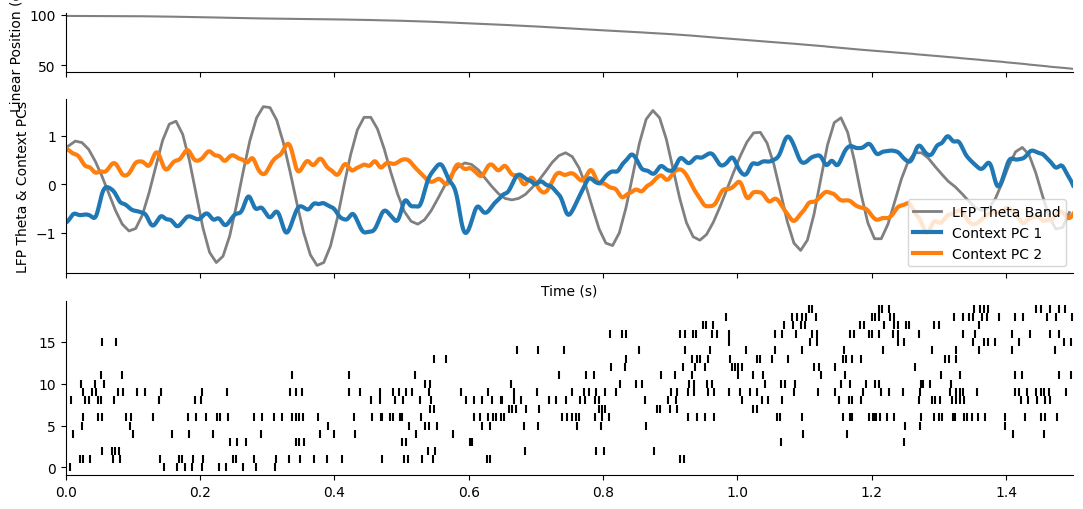

In [ ]:
analysis = analysis_all

i = 30
# t_rng = 2,5
# t_rng = 2.5, 3.5

i = 5
t_rng = -1, 2
t_rng = 1.6, 2.6
t_rng = 3, 6
t_rng = 3.5, 5

smooth_width = 51

pc_inds = np.array([0, 1])
# t_rng = 3,4

fig, ax = plt.subplots(
    nrows=3,
    sharex=True,
    height_ratios=[1, 3, 3],
    figsize=(13, 6),
)

# ax = ax_list[1:]

interval = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
interval = interval[i]
st = left_running_intervals[i][0] + t_rng[0]
en = left_running_intervals[i][0] + t_rng[1]

t_theta = theta_band_obj.timestamps
ind_theta = np.logical_and(
    t_theta >= st,
    t_theta <= en,
)
ax[1].plot(
    t_theta[ind_theta] - st,
    theta_band_obj.data[ind_theta][:, ref_ind] / 100,
    c="grey",
    lw=2,
    zorder=-10,
    label="LFP Theta Band",
)

ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, smooth_width, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(2):
    ax[1].plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=1 - j,
        label=f"Context PC {j+1}",
        lw=3,
    )
    # break


pos_ind = np.logical_and(
    pos_df.index >= st,
    pos_df.index <= en,
)
ax[0].plot(
    pos_df.index[pos_ind] - st,
    pos_df.linear_position[pos_ind],
    c="gray",
    # s=5,
    zorder=-5,
)
# plt.xlim(4,5)
# plt.xlim(2,3)
# ind_theta = np.logical_and(
#     phase_df.index >= left_running_intervals[i][0], phase_df.index <= left_running_intervals[i][0] +dur,
# )
# plt.plot(phase_df.index[ind_theta], phase_df["electrode 12"].values[ind_theta])

ind_theta = np.logical_and(
    phase_df.index >= st,
    phase_df.index <= en,
)
# plt.plot(
#     phase_df.index[ind_theta] - st,
#     phase_df["phase"].values[ind_theta],
# )

ax[1].legend(loc="lower right")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position (cm)")
ax[1].set_ylabel("LFP Theta & Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])


min_spikes = 10
plot_spikes = []
for s in spikes_list:
    s_st = np.digitize(st, s)
    s_en = np.digitize(en, s)
    if s_en - s_st < min_spikes:
        continue
    plot_spikes.append(s[s_st:s_en])

order = np.argsort([np.mean(s) for s in plot_spikes])
plot_spikes = [plot_spikes[i] for i in order]
for i, s in enumerate(plot_spikes):
    ax[2].scatter(s - st, np.ones(len(s)) * i, marker="|", color="k")

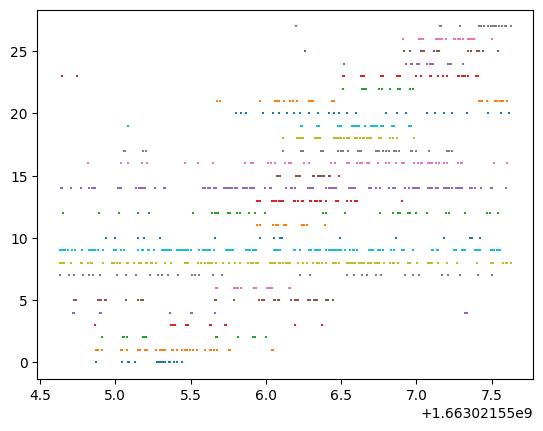

In [ ]:
min_spikes = 10
plot_spikes = []
for s in spikes_list:
    s_st = np.digitize(st, s)
    s_en = np.digitize(en, s)
    if s_en - s_st < min_spikes:
        continue
    # print(f"Spikes in interval [{st}, {en}]: {len(s[s_st:s_en])}")
    # plt.scatter(s[s_st:s_en], np.ones(len(s[s_st:s_en])) * i_spikes, s=1)
    # i_spikes += 1
    plot_spikes.append(s[s_st:s_en])

order = np.argsort([np.mean(s) for s in plot_spikes])
plot_spikes = [plot_spikes[i] for i in order]
for i, s in enumerate(plot_spikes):
    plt.scatter(s, np.ones(len(s)) * i, s=1, marker="|")

## Power Spectrums

In [55]:
f, mid, lo, hi = analysis.power_spectrum(
    intervals=all_running_intervals,
    pca=True,
    window_size=int(2 / np.mean(np.diff(t_interp[:10]))),
    nfft=50000,
)

Text(0.5, 1.0, 'context power spectrums')

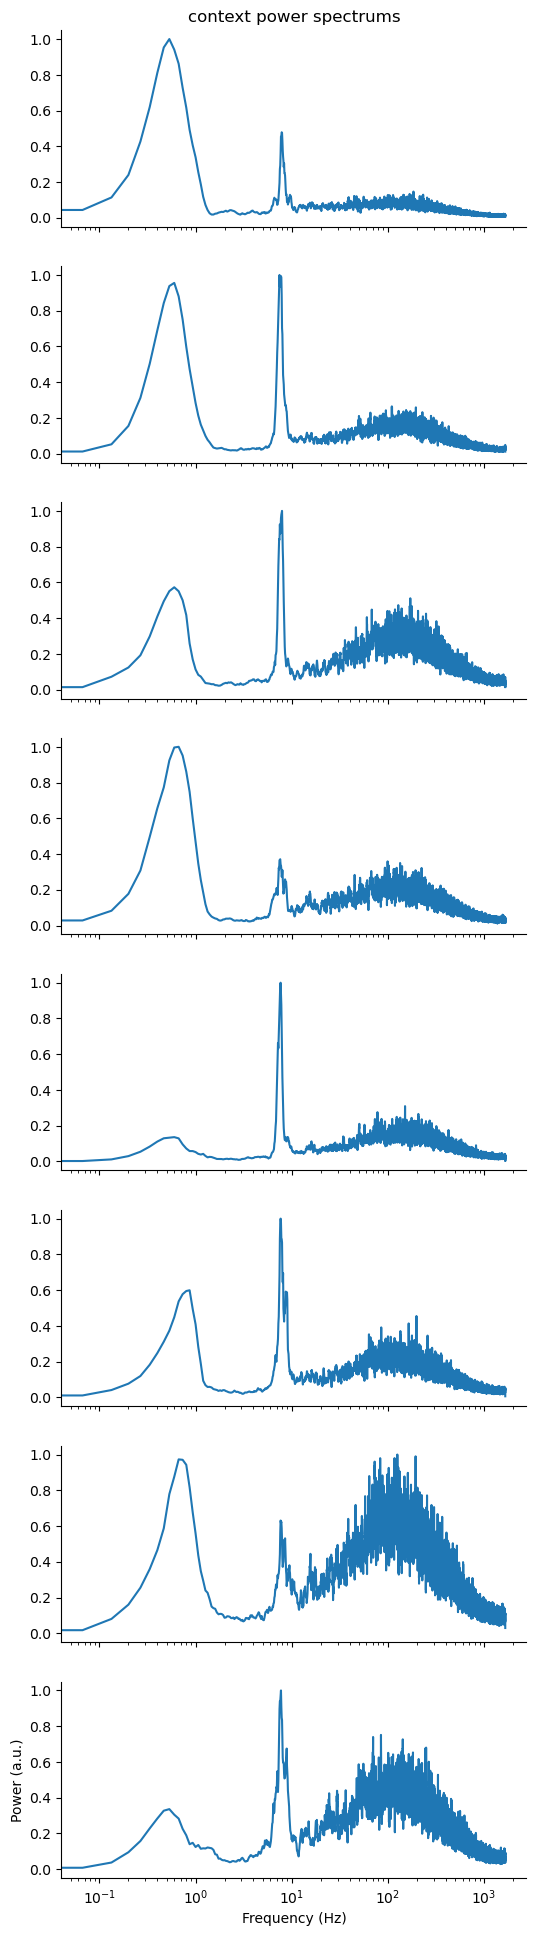

In [56]:
n_plot = 8

norm_mid = mid.T * f[:, None]
norm_mid = norm_mid / np.max(norm_mid, axis=0)
# norm_mid = norm_mid[:,:]


fig, ax = plt.subplots(nrows=n_plot, figsize=(6, 3 * n_plot), sharex=True)
for i, a in enumerate(ax):
    a.plot(f, norm_mid[:, i])
    a.set_xscale("log")
    a.spines[["top", "right"]].set_visible(False)
# plt.plot(f, norm_mid)
plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (a.u.)")
ax[0].set_title("context power spectrums")

Text(0.5, 1.0, 'context power spectrums')

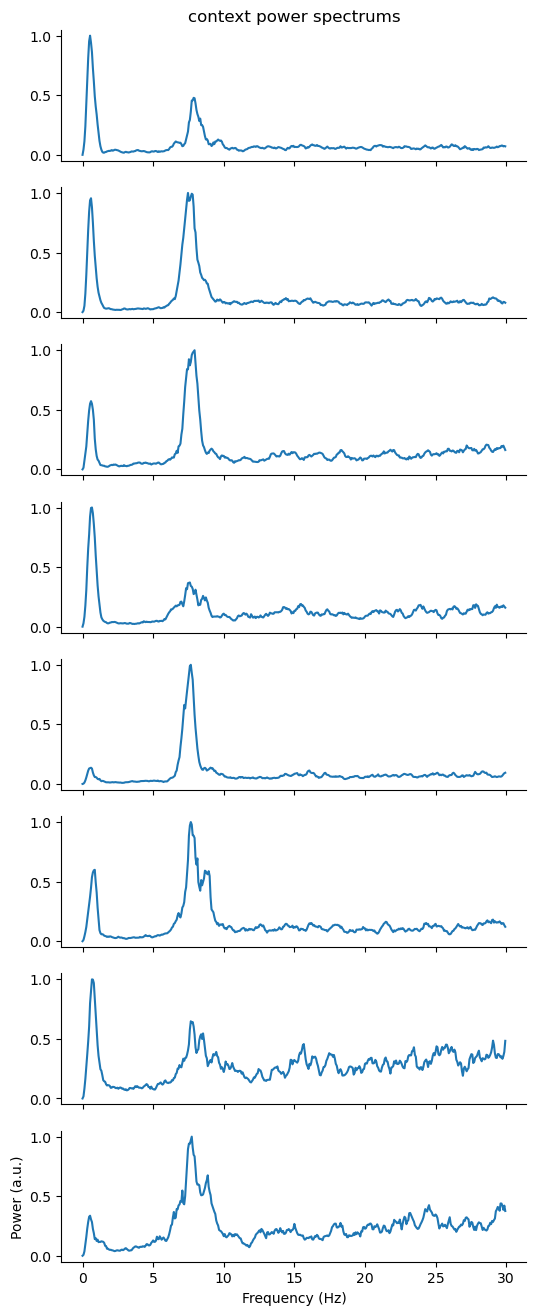

In [57]:
n_plot = 8
f_rng = (0, 30)

ind_plot = np.where((f >= f_rng[0]) & (f <= f_rng[1]))[0]
norm_mid = mid[:, ind_plot].T * f[ind_plot, None]
norm_mid = norm_mid / np.max(norm_mid, axis=0)
# norm_mid = norm_mid[:,:]


fig, ax = plt.subplots(nrows=n_plot, figsize=(6, 2 * n_plot), sharex=True)
for i, a in enumerate(ax):
    a.plot(f[ind_plot], norm_mid[:, i])
    # a.set_xscale("log")
    a.spines[["top", "right"]].set_visible(False)
# plt.plot(f, norm_mid)
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (a.u.)")
ax[0].set_title("context power spectrums")

## Cross Correlations

In [ ]:
analysis_ = analysis_ripples

# lags, corr = analysis.cross_correlation(
#     intervals=all_running_intervals, pca=True, max_lag_seconds=1, dim_limit=10, processes=20

# )

ripple_lags, ripple_corr = analysis_.cross_correlation(
    intervals=ripple_intervals,
    pca=True,
    max_lag_seconds=0.1,
    dim_limit=10,
    processes=20,
)

In [11]:
lags, corr = analysis_.cross_correlation(
    intervals=all_running_intervals,
    pca=True,
    max_lag_seconds=1,
    dim_limit=10,
    processes=20,
)

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 100/100 [00:42<00:00,  2.37it/s]


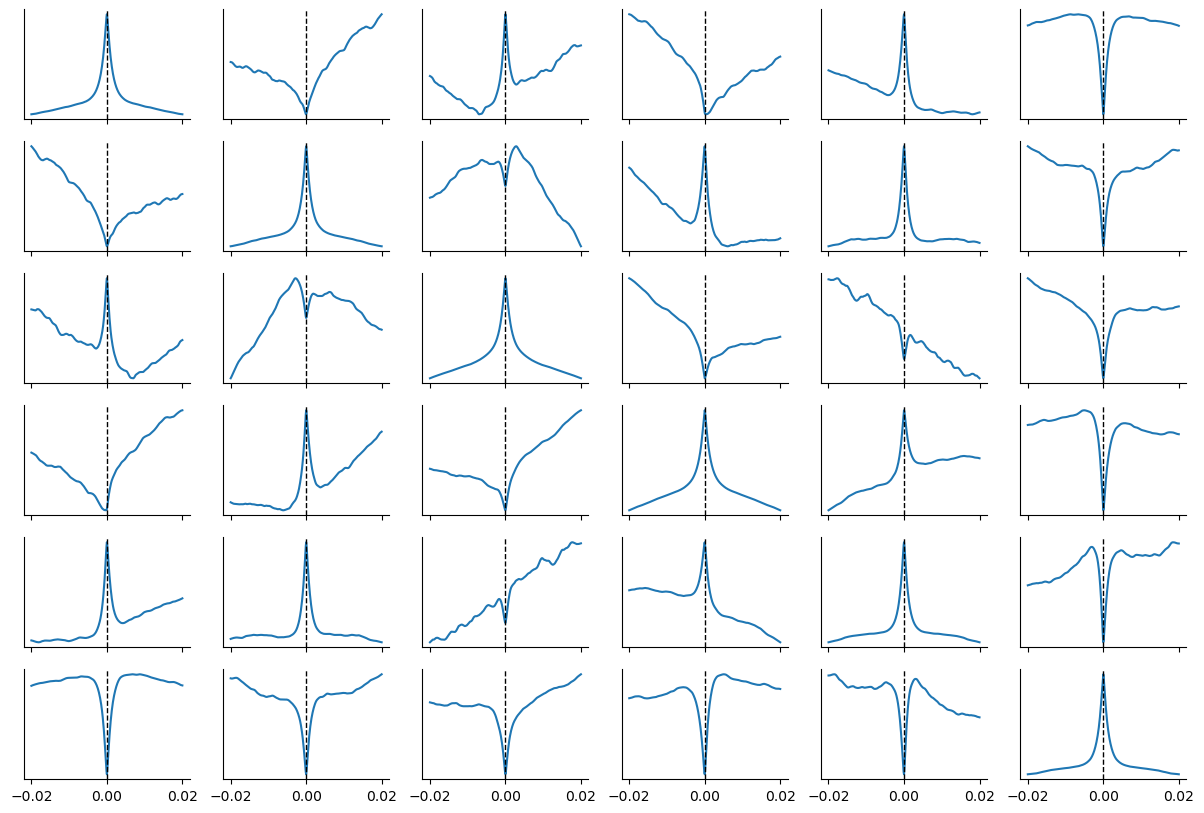

In [16]:
t_rng = (-0.02, 0.02)
# t_rng = (-0.05, 0.05)
# t_rng = -0.1, 0.1
# t_rng = -1, 1
# t_rng = -.25,.25

n_plot = 6
ind_plot = np.where((lags >= t_rng[0]) & (lags <= t_rng[1]))[0]

fig, ax = plt.subplots(nrows=n_plot, ncols=n_plot, figsize=(15, 10), sharex=True)

for i in range(n_plot):
    for j in range(n_plot):
        ax[i, j].plot(lags[ind_plot], corr[i, j][ind_plot])
        ax[i, j].spines[["top", "right"]].set_visible(False)
        # ax[i,j].set_title(f"PC {i+1} vs PC {j+1}")
        ax[i, j].axvline(0, c="k", ls="--", lw=1)
        ax[i, j].set_yticks([])
# plt.xlim(-.1,.1)
# plt.yscale('log')

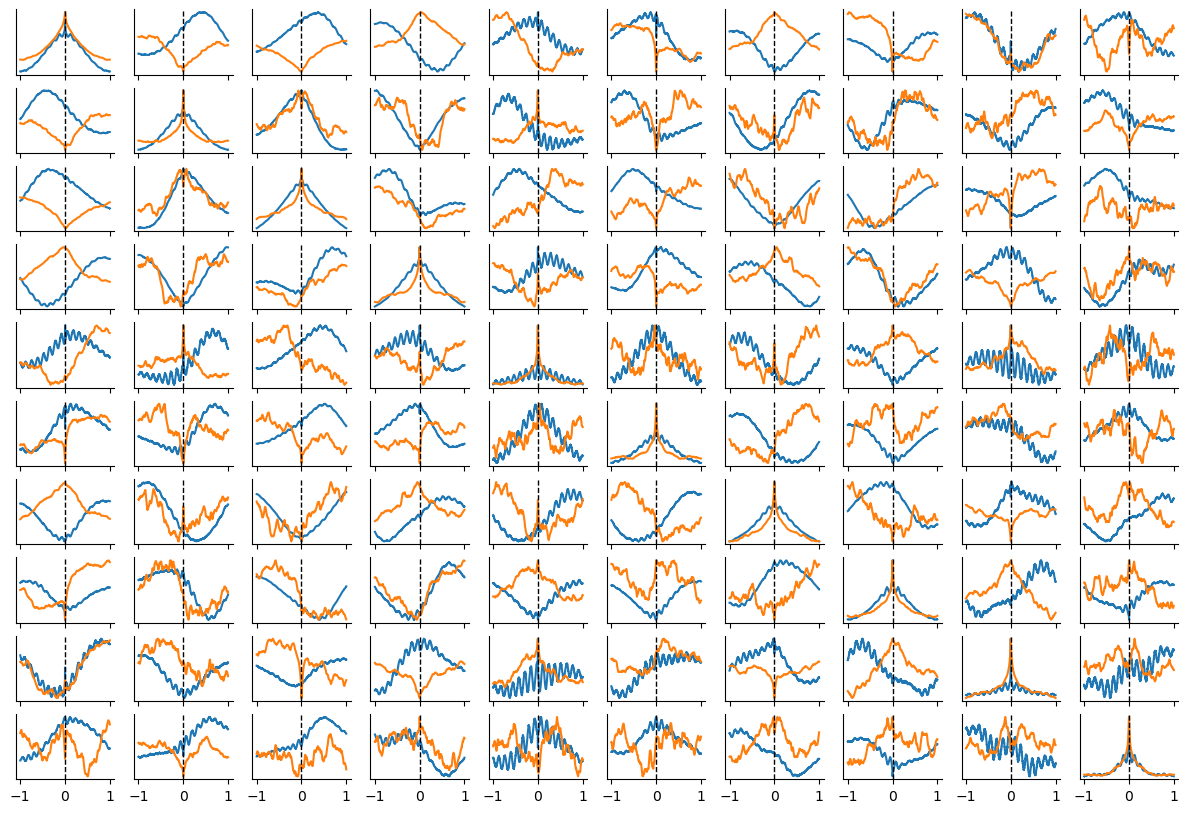

In [ ]:
t_rng = -1, 1

t_rng_ripple = (-0.1, 0.1)
# t_rng = -.2,.2

n_plot = 10
ind_plot = np.where((lags >= t_rng[0]) & (lags <= t_rng[1]))[0]
ind_plot_ripple = np.where(
    (ripple_lags >= t_rng_ripple[0]) & (ripple_lags <= t_rng_ripple[1])
)[0]

# t_ = np.linspace(t_rng[0], t_rng[1], ind_plot.shape[0])
# t_ripple_ = np.linspace(t_rng_ripple[0], t_rng_ripple[1], ind_plot_ripple.shape[0])
t_ = np.linspace(-1, 1, ind_plot.shape[0])
t_ripple_ = np.linspace(-1, 1, ind_plot_ripple.shape[0])

fig, ax = plt.subplots(nrows=n_plot, ncols=n_plot, figsize=(15, 10), sharex=True)

for i in range(n_plot):
    for j in range(n_plot):
        c_ij = corr[i, j][ind_plot]
        c_ij = c_ij / np.max(np.abs(c_ij))
        ax[i, j].plot(t_, c_ij)

        c_ripple_ij = ripple_corr[i, j][ind_plot_ripple]
        c_ripple_ij = c_ripple_ij / np.max(np.abs(c_ripple_ij))
        ax[i, j].plot(t_ripple_, c_ripple_ij)
        ax[i, j].spines[["top", "right"]].set_visible(False)
        # ax[i,j].set_title(f"PC {i+1} vs PC {j+1}")
        ax[i, j].axvline(0, c="k", ls="--", lw=1)
        ax[i, j].set_yticks([])

In [164]:
def violin_scatter(
    data,
    pos=0,
    color="cornflowerblue",
    bw_method=None,
    ax=None,
    return_locs=False,
    widths=0.5,
    mark_mean=False,
    alpha=None,
):
    """plot a violin plot with scatter points jiittered around the width of the violin plot"""
    if ax is None:
        ax = plt.gca()
    vp = ax.violinplot(
        data,
        positions=[pos],
        showmedians=False,
        showextrema=False,
        points=1000,
        bw_method=bw_method,
        widths=widths,
    )
    body = vp["bodies"][0]
    body.set_facecolor(color)
    path = body.get_paths()[0].vertices
    x_data, y_data = path[:, 0], path[:, 1]
    y_data = y_data[x_data.size // 2 :]  # -pos
    x_data = x_data[x_data.size // 2 :] - pos
    width = x_data[np.digitize(data, y_data, right=False)]
    x_pos = np.random.normal(0, 0.3, len(data)) * width + pos
    alpha = 1 - (len(data)) / (len(data) + 20)
    if alpha is None:
        alpha = np.min([0.5, alpha])
        alpha = np.max([0.01, alpha])
    ax.scatter(x_pos, data, alpha=alpha, color=color)
    if mark_mean:
        ax.scatter(pos, np.mean(data), color=color)
    if return_locs:
        return x_pos, data
    return

0.1
0.11836734693877551
0.13673469387755102
0.15510204081632656
0.17346938775510207
0.19183673469387758
0.21020408163265308
0.2285714285714286
0.2469387755102041
0.2653061224489796
0.2836734693877551
0.3020408163265306
0.3204081632653062
0.3387755102040817
0.3571428571428572
0.3755102040816327
0.3938775510204082
0.41224489795918373
0.43061224489795924
0.44897959183673475
0.46734693877551026
0.48571428571428577
0.5040816326530613
0.5224489795918368
0.5408163265306123
0.5591836734693878
0.5775510204081633
0.5959183673469388
0.6142857142857143
0.6326530612244898
0.6510204081632653
0.6693877551020408
0.6877551020408164
0.7061224489795919
0.7244897959183674
0.7428571428571429
0.7612244897959184
0.7795918367346939
0.7979591836734694
0.8163265306122449
0.8346938775510204
0.8530612244897959
0.8714285714285714
0.889795918367347
0.9081632653061225
0.926530612244898
0.9448979591836735
0.963265306122449
0.9816326530612246
1.0


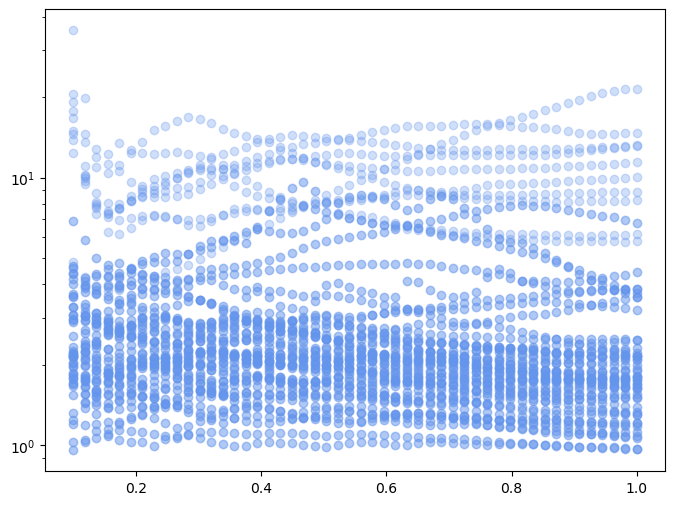

In [177]:
dilation_list = np.linspace(0.1, 1, 50)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

for dilation in dilation_list:
    print(dilation)
    t_rng = -dilation, dilation

    t_rng_ripple = (-0.05, 0.05)
    # t_rng = -.2,.2

    ind_plot = np.where((lags >= t_rng[0]) & (lags <= t_rng[1]))[0]
    ind_plot_ripple = np.where(
        (ripple_lags >= t_rng_ripple[0]) & (ripple_lags <= t_rng_ripple[1])
    )[0]

    t_ = np.linspace(-1, 1, ind_plot.shape[0])
    t_ripple_ = np.linspace(-1, 1, ind_plot_ripple.shape[0])

    n_plot = 10

    similarity = np.zeros((n_plot, n_plot))
    for i in range(n_plot):
        for j in range(n_plot):
            c_ij = corr[i, j][ind_plot]
            # c_ij = np.interp(
            #     t_ripple_,
            #     t_,
            #     c_ij,
            #     # kind="linear",
            # )

            c_ripple_ij = ripple_corr[i, j][ind_plot_ripple]
            c_ripple_ij = np.interp(
                t_,
                t_ripple_,
                c_ripple_ij,
                # kind="linear",
            )
            # c_ripple_ij = c_ripple_ij / np.max(np.abs(c_ripple_ij))

            # similarity[i, j] = np.corrcoef(c_ij, c_ripple_ij)[0,1]

            c_ij = c_ij - np.mean(c_ij)
            c_ripple_ij = c_ripple_ij - np.mean(c_ripple_ij)
            c_ij = c_ij / np.max(np.abs(c_ij))
            c_ripple_ij = c_ripple_ij / np.max(np.abs(c_ripple_ij))
            similarity[i, j] = 1 / np.mean(np.abs((c_ij - c_ripple_ij)))

    # violin_scatter(similarity.flatten(), pos=dilation, widths=1/dilation_list.size/2, color="cornflowerblue", ax=ax)
    plt.scatter(
        [dilation] * similarity.flatten().shape[0],
        similarity.flatten(),
        color="cornflowerblue",
        alpha=0.3,
    )

plt.yscale("log")

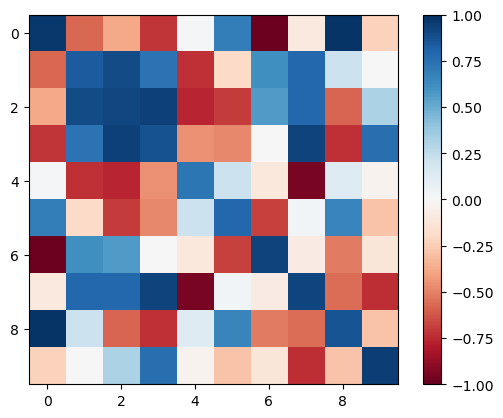

In [161]:
plt.imshow(similarity, vmin=-1, vmax=1, cmap="RdBu")
plt.colorbar()

(array([ 4.,  0.,  0., 10.,  4.,  0.,  6.,  4.,  2.,  2.,  4.,  2.,  2.,
         8.,  4.,  6.,  2.,  0.,  4.,  2.,  0.,  0.,  0.,  2.,  2.,  4.,
         5.,  6.,  5., 10.]),
 array([-0.97867631, -0.91349756, -0.84831881, -0.78314005, -0.7179613 ,
        -0.65278255, -0.5876038 , -0.52242505, -0.45724629, -0.39206754,
        -0.32688879, -0.26171004, -0.19653129, -0.13135253, -0.06617378,
        -0.00099503,  0.06418372,  0.12936247,  0.19454123,  0.25971998,
         0.32489873,  0.39007748,  0.45525623,  0.52043499,  0.58561374,
         0.65079249,  0.71597124,  0.78114999,  0.84632874,  0.9115075 ,
         0.97668625]),
 <BarContainer object of 30 artists>)

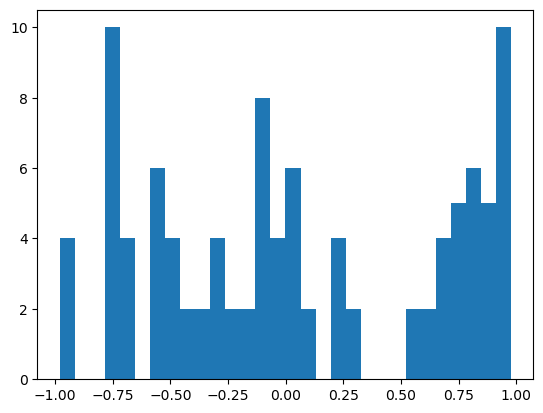

In [162]:
plt.hist(similarity.flatten(), bins=30)

## Context value vs. position

In [37]:
pos_bins = np.linspace(10, 110, 50)
pca = True
analysis_ = analysis_running

left_binned_context, bins = analysis_.bin_context_by_feature(
    pos_df.linear_position.values,
    pos_df.index,
    pca=pca,
    valid_intervals=left_running_intervals,
    bins=pos_bins,
    # interpolated=True,
)

right_binned_context, bins = analysis_.bin_context_by_feature(
    pos_df.linear_position.values,
    pos_df.index,
    pca=pca,
    valid_intervals=right_running_intervals,
    bins=pos_bins,
    # interpolated=True,
)

mid_list = []
lo_list = []
hi_list = []

for j, binned_context in enumerate([left_binned_context, right_binned_context]):
    mid = np.array([np.nanmedian(b, axis=0) for b in binned_context])
    hi = np.array(
        [
            np.nanpercentile(
                b,
                75,
                axis=0,
            )
            for b in binned_context
        ]
    )
    lo = np.array(
        [
            np.nanpercentile(
                b,
                25,
                axis=0,
            )
            for b in binned_context
        ]
    )
    mid_list.append(mid)
    lo_list.append(lo)
    hi_list.append(hi)

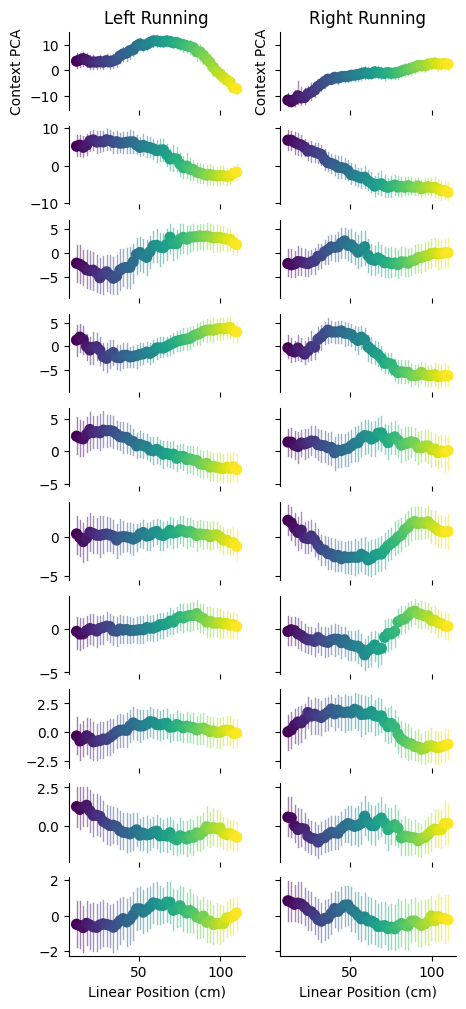

In [38]:
n_plot = 10
n_plot = min(context_dim, n_plot)

fig, ax_list = plt.subplots(
    nrows=n_plot, ncols=2, sharex=True, sharey="row", figsize=(5, 1.2 * n_plot)
)
for j, name in enumerate(["Left", "Right"]):
    ax = ax_list[:, j]
    mid = mid_list[j]
    lo = lo_list[j]
    hi = hi_list[j]
    c = np.linspace(0, 1, mid.shape[0])
    for i, a in enumerate(ax):
        a.scatter(bins[1:], mid[:, i], s=50, c=c)
        # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, zorder=-1)
        for k in range(len(bins[1:])):
            a.plot(
                [bins[k + 1], bins[k + 1]],
                [lo[k, i], hi[k, i]],
                alpha=0.5,
                zorder=-1,
                c=plt.cm.viridis(c[k]),
                lw=1,
            )
        a.spines[["top", "right", "bottom"]].set_visible(False)
    ax[-1].spines["bottom"].set_visible(True)

    ax[-1].set_xlabel("Linear Position (cm)")
    ax[0].set_title(f"{name} Running")
    ax[0].set_ylabel("Context PCA")

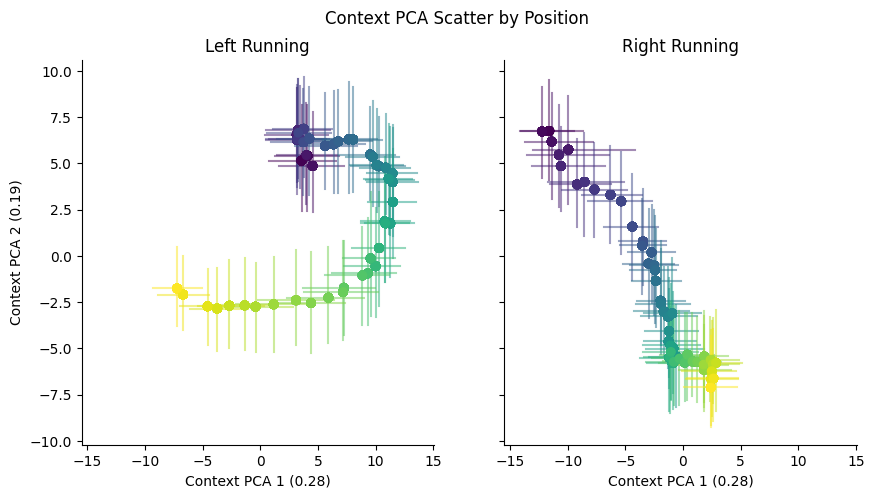

In [39]:
axes = 1, 2
axes = 0, 1
# axes = 3, 4
fig, ax = plt.subplots(figsize=(10, 5), ncols=2, sharex=True, sharey=True)


for j, a in enumerate(ax):
    mid = mid_list[j]
    lo = lo_list[j]
    hi = hi_list[j]
    for i, c_i in enumerate(c):
        a.scatter(mid[:, axes[0]], mid[:, axes[1]], c=c, alpha=1)
        a.plot(
            [mid[i, axes[0]], mid[i, axes[0]]],
            [lo[i, axes[1]], hi[i, axes[1]]],
            c=plt.cm.viridis(c_i),
            alpha=0.5,
            zorder=-1,
        )
        a.plot(
            [lo[i, axes[0]], hi[i, axes[0]]],
            [mid[i, axes[1]], mid[i, axes[1]]],
            c=plt.cm.viridis(c_i),
            alpha=0.5,
            zorder=-1,
        )

        a.spines[["top", "right"]].set_visible(False)

fig.suptitle("Context PCA Scatter by Position")
ax[0].set_title("Left Running")
ax[1].set_title("Right Running")
for a in ax:
    a.set_xlabel(
        f"Context PCA {axes[0]+1} ({analysis.pca.explained_variance_ratio_[axes[0]]:.2f})"
    )
ax[0].set_ylabel(
    f"Context PCA {axes[1]+1} ({analysis.pca.explained_variance_ratio_[axes[1]]:.2f})"
)

fig.savefig(
    figure_folder / f"contextPCA_scatter_byPosition_PC{axes[0]+1}_PC{axes[1]+1}.svg",
)

## Context value vs LFP Bands

### Theta

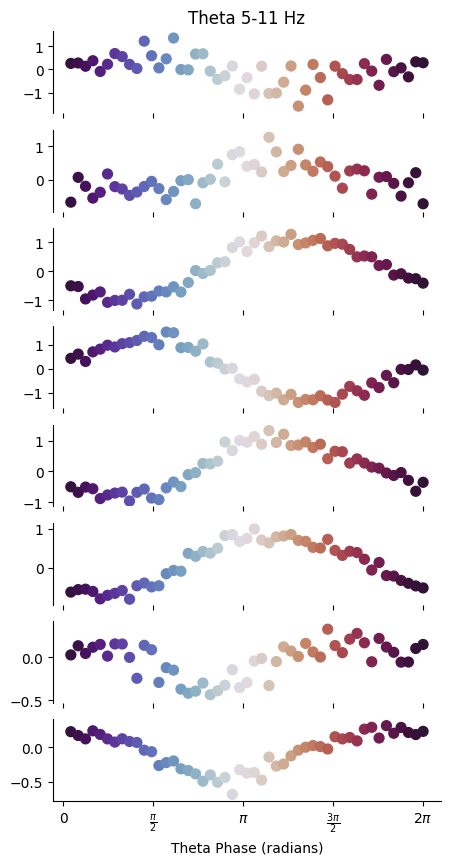

In [40]:
plotting = "mean"
phase_bins = np.linspace(0, 2 * np.pi, 50)
analysis_ = analysis_running

binned_context, bins = analysis_.bin_context_by_feature(
    phase_df.phase.values,
    phase_df.index,
    pca=True,
    # interpolated=True,
    valid_intervals=all_running_intervals,
    bins=phase_bins,
)

if plotting == "median":
    mid = [np.nanmedian(b, axis=0) for b in binned_context]
    hi = [
        np.nanpercentile(
            b,
            75,
            axis=0,
        )
        for b in binned_context
    ]
    lo = [
        np.nanpercentile(
            b,
            25,
            axis=0,
        )
        for b in binned_context
    ]
elif plotting == "mean":
    mid = [np.nanmean(b, axis=0) for b in binned_context]
    hi = [
        np.nanmean(b, axis=0) + np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    lo = [
        np.nanmean(b, axis=0) - np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]

mid = np.array(mid)
lo = np.array(lo)
hi = np.array(hi)
fig, ax = plt.subplots(nrows=min(context_dim, 8), ncols=1, figsize=(5, 10), sharex=True)
c = [plt.cm.twilight_shifted(phase / (2 * np.pi)) for phase in bins[1:]]
for i, a in enumerate(ax):
    a.scatter(bins[1:], mid[:, i], s=50, c=c)
    a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, color=c)
    a.spines[["top", "right", "bottom"]].set_visible(False)
ax[-1].spines["bottom"].set_visible(True)

plt.xlabel("Theta Phase (radians)")
plt.xticks(
    np.linspace(0, 2 * np.pi, 5),
    ["0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"],
)
ax[0].set_title(theta_key["filter_name"])

fig.savefig(
    figure_folder / "contextPCA_thetaPhase.svg",
)

### Slow Gamma Band

Text(0.5, 1.0, 'Slow Gamma 25-55 Hz')

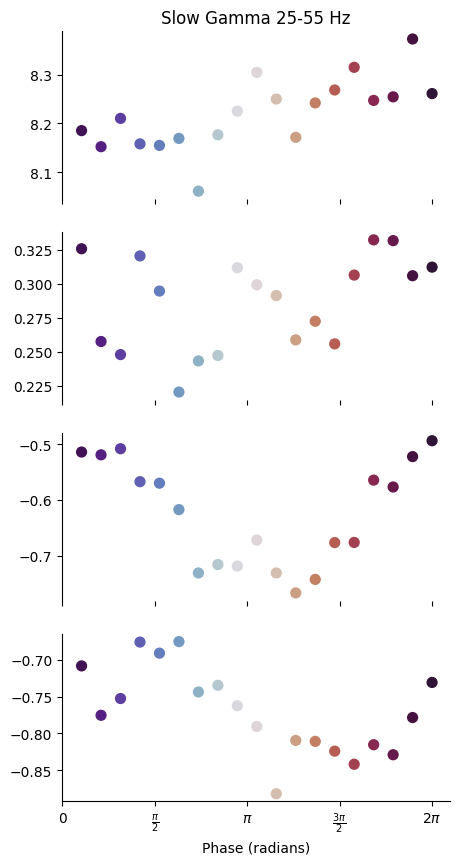

In [41]:
plotting = "mean"
n_plot = 4
phase_bins = np.linspace(0, 2 * np.pi, 20)

binned_context, bins = analysis.bin_context_by_feature(
    sg_phase_df.phase.values,
    sg_phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=all_running_intervals,
    bins=phase_bins,
)

if plotting == "median":
    mid = [np.nanmedian(b, axis=0) for b in binned_context]
    hi = [
        np.nanpercentile(
            b,
            75,
            axis=0,
        )
        for b in binned_context
    ]
    lo = [
        np.nanpercentile(
            b,
            25,
            axis=0,
        )
        for b in binned_context
    ]
elif plotting == "mean":
    mid = [np.nanmean(b, axis=0) for b in binned_context]
    hi = [
        np.nanmean(b, axis=0) + np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    lo = [
        np.nanmean(b, axis=0) - np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]

mid = np.array(mid)
lo = np.array(lo)
hi = np.array(hi)
fig, ax = plt.subplots(
    nrows=min(context_dim, n_plot), ncols=1, figsize=(5, 10), sharex=True
)
c = [plt.cm.twilight_shifted(phase / (2 * np.pi)) for phase in bins[1:]]
for i, a in enumerate(ax):
    a.scatter(bins[1:], mid[:, i], s=50, c=c)
    # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, color=c)
    a.spines[["top", "right", "bottom"]].set_visible(False)
ax[-1].spines["bottom"].set_visible(True)

plt.xlabel("Phase (radians)")
plt.xticks(
    np.linspace(0, 2 * np.pi, 5),
    ["0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"],
)
ax[0].set_title(slow_gamma_key["filter_name"])

### Fast Gamma Band

Text(0.5, 1.0, 'Fast Gamma 65-100 Hz')

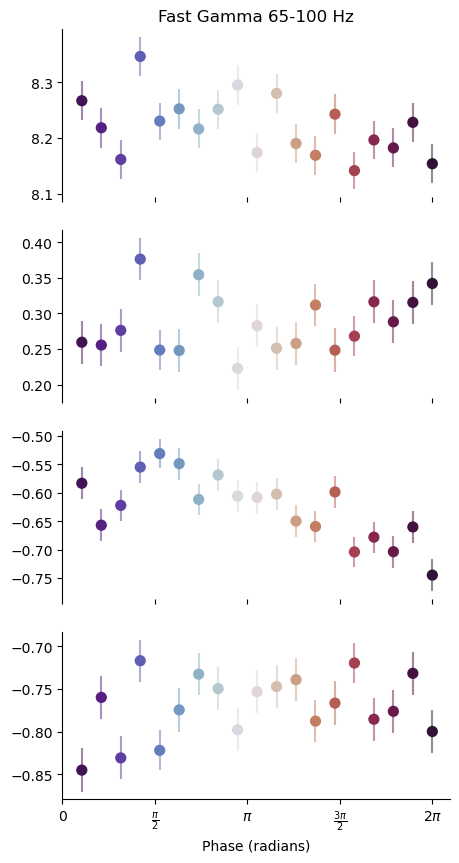

In [63]:
n_plot = 4
plotting = "mean"
hase_bins = np.linspace(0, 2 * np.pi, 30)

binned_context, bins = analysis.bin_context_by_feature(
    fg_phase_df.phase.values,
    fg_phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=all_running_intervals,
    bins=phase_bins,
)

if plotting == "median":
    mid = [np.nanmedian(b, axis=0) for b in binned_context]
    hi = [
        np.nanpercentile(
            b,
            75,
            axis=0,
        )
        for b in binned_context
    ]
    lo = [
        np.nanpercentile(
            b,
            25,
            axis=0,
        )
        for b in binned_context
    ]
elif plotting == "mean":
    mid = [np.nanmean(b, axis=0) for b in binned_context]
    hi = [
        np.nanmean(b, axis=0) + np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    lo = [
        np.nanmean(b, axis=0) - np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
mid = np.array(mid)
lo = np.array(lo)
hi = np.array(hi)
fig, ax = plt.subplots(
    nrows=min(context_dim, n_plot), ncols=1, figsize=(5, 10), sharex=True
)
c = [plt.cm.twilight_shifted(phase / (2 * np.pi)) for phase in bins[1:]]
for i, a in enumerate(ax):
    a.scatter(bins[1:], mid[:, i], s=50, c=c)
    a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, color=c)
    a.spines[["top", "right", "bottom"]].set_visible(False)
ax[-1].spines["bottom"].set_visible(True)

plt.xlabel("Phase (radians)")
plt.xticks(
    np.linspace(0, 2 * np.pi, 5),
    ["0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"],
)
ax[0].set_title(fast_gamma_key["filter_name"])

## Theta x Position binning

In [45]:
n_pos = 100
n_theta = 50

n_pos = 20
n_theta = 15

# n_pos = 150
# n_theta = 75

left_binned_context, b1, b2, counts_left = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    phase_df.phase.values,
    phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=left_running_intervals,
    bins_1=np.linspace(10, 110, n_pos),
    bins_2=np.linspace(0, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)


right_binned_context, b1, b2, counts_right = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    phase_df.phase.values,
    phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=right_running_intervals,
    bins_1=np.linspace(10, 110, n_pos),
    bins_2=np.linspace(0.01, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)

In [122]:
np.mean(np.diff(phase_df.index.values)), np.mean(np.diff(pos_df.index.values))
len(left_running_intervals), len(right_running_intervals)

(138, 125)

905321


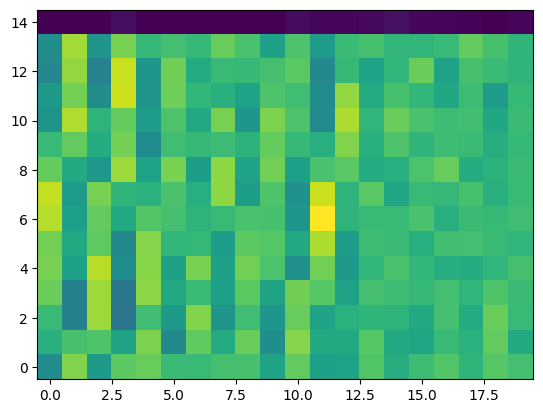

In [46]:
counts = counts_right
counts = counts_left
# counts = counts_left + counts_right

print(counts.sum())
counts = counts / counts.sum(axis=1)[:, None]

plt.imshow((counts.T), aspect="auto", origin="lower")
# counts_left.sum()

Text(0.5, 1.0, 'running left-to-right as plotted')

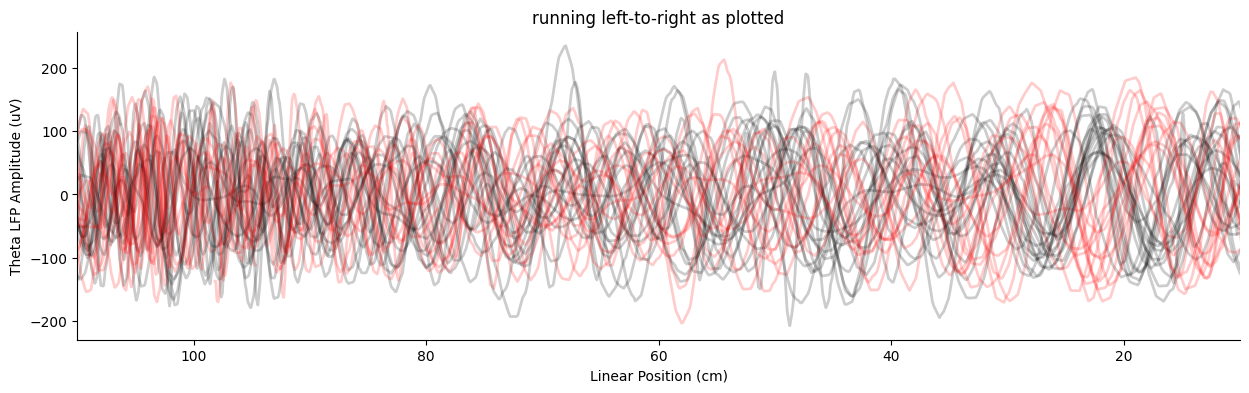

In [47]:
long_left_intervals = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
pos_separate = 23

# long_left_intervals = [i_ for i_ in right_running_intervals if i_[1] - i_[0] > 0.5]
# pos_separate = 105

# pos_separate = 93

fig = plt.figure(figsize=(15, 4))
pos_vals = []
lfp_vals = []
for interval in long_left_intervals[:]:
    st = interval[0]
    en = interval[1]

    ind_pos = np.logical_and(
        pos_df.index >= st,
        pos_df.index <= en,
    )
    t_pos = pos_df.index[ind_pos]
    pos_plot = pos_df.linear_position[ind_pos]

    # ind_theta = np.logical_and(
    #     phase_df.index >= st,
    #     phase_df.index <= en,
    # )
    # t_theta = phase_df.index[ind_theta]
    # phase_plot = phase_df.phase[ind_theta]
    ind_theta = np.logical_and(
        theta_band_obj.timestamps >= st,
        theta_band_obj.timestamps <= en,
    )
    t_theta = theta_band_obj.timestamps[ind_theta]
    phase_plot = theta_band_obj.data[ind_theta][:, ref_ind]

    phase_plot = np.interp(t_pos, t_theta, phase_plot)

    ind = np.argmin(np.abs(pos_plot - pos_separate))
    val = phase_plot[ind]
    # c = plt.cm.viridis(phase_plot/100)
    c = "k" if val > 0 else "r"
    # c='k'
    plt.plot(pos_plot, phase_plot, c=c, alpha=0.2, lw=2)
    pos_vals.append(pos_plot)
    lfp_vals.append(phase_plot)

pos_vals = np.concatenate(pos_vals)
lfp_vals = np.concatenate(lfp_vals)

plt.xlim(pos_bins[0], pos_bins[-1])
plt.xlim(pos_bins[-1], pos_bins[0])
plt.gca().spines[["top", "right"]].set_visible(False)

plt.xlabel("Linear Position (cm)")
plt.ylabel("Theta LFP Amplitude (uV)")
plt.title("running left-to-right as plotted")
# plt.xlim(0,60)

In [52]:
H.shape

(99, 49)

/tmp/ipykernel_1792862/3198576621.py:6: RuntimeWarning: Mean of empty slice
  np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)
/tmp/ipykernel_1792862/3198576621.py:15: RuntimeWarning: Mean of empty slice
  np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)


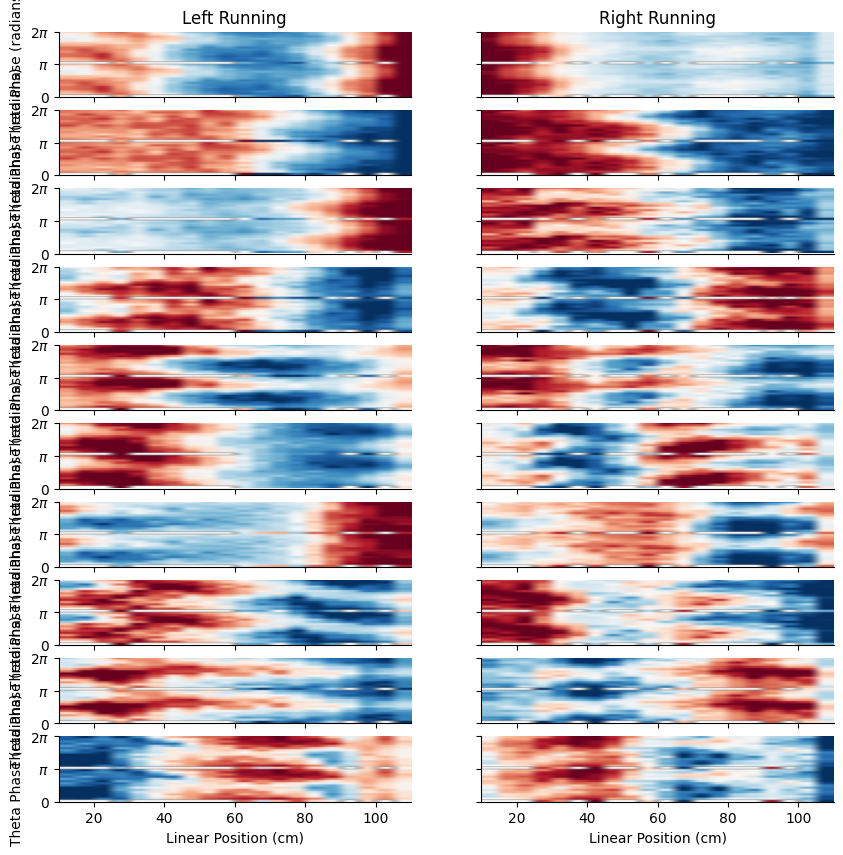

In [ ]:
n_plot = 10

mid_left = np.array(
    [
        [
            np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)
            for b in row
        ]
        for row in left_binned_context
    ]
)
mid_right = np.array(
    [
        [
            np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)
            for b in row
        ]
        for row in right_binned_context
    ]
)
mid.shape
fig, ax_list = plt.subplots(
    nrows=min(context_dim, n_plot),
    sharex=True,
    sharey=True,
    figsize=(10, n_plot * 1),
    ncols=2,
)


for j, (name, data) in enumerate(zip(["Left", "Right"], [mid_left, mid_right])):
    ax = ax_list[:, j]
    ax[0].set_title(f"{name} Running")
    for i, a in enumerate(ax):
        val = data[:, :, i].T
        val = val - np.nanmean(val)
        val = val / np.nanpercentile(np.abs(val), 97)
        # val = np.roll(val, val.shape[0] // 2, axis=0)
        val = np.concatenate(
            [
                val,
                val,
            ],
            axis=0,
        )
        a.imshow(
            val,
            cmap="RdBu",
            extent=[b1[0], b1[-1], b2[0], b2[-1]],
            aspect="auto",
            clim=(-0.9, 0.9),
        )
        a.spines[
            [
                "top",
                "right",
            ]
        ].set_visible(False)

for a in ax_list[-1]:
    a.spines["bottom"].set_visible(True)
    a.set_xlabel("Linear Position (cm)")
for a in ax_list[:, 0]:
    a.set_ylabel("Theta Phase (radians)")
    # a.set_yticks(
    #     np.linspace(0, 2 * np.pi, 3),
    #     [r"-$\pi$", "0", r"$\pi$"],
    # )
    a.set_yticks(
        np.linspace(0, 2 * np.pi, 3),
        ["0", r"$\pi$", r"$2\pi$"],
    )

# plt.imshow(mid[:,:,1].T,cmap='RdBu',extent=[b1[0],b1[-1],b2[0],b2[-1]],aspect='auto')
# plt.colorbar()

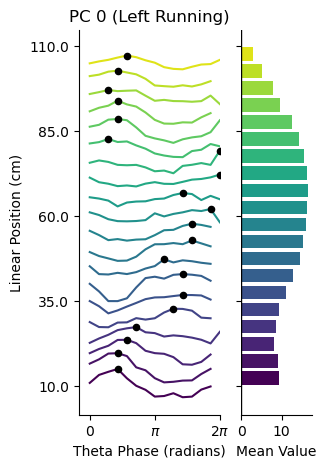

In [100]:
pc = 0
data = mid_left

# fig = plt.figure(figsize=(2, 5))

fig, ax = plt.subplots(figsize=(3, 5), ncols=2, width_ratios=[2, 1], sharey=True)

val = data[:, :, pc].T

scale_factor = 0
for i in range(val.shape[-1]):
    val_i = val[:, i].copy()
    mid_i = np.nanmean(val_i)
    val_i = val_i - np.nanmean(val_i)
    scale_i = np.nanpercentile(np.abs(val_i), 97)
    if scale_i > scale_factor:
        scale_factor = scale_i


for i in range(val.shape[-1]):
    val_i = val[:, i].copy()
    mid_i = np.nanmean(val_i)

    val_i = val_i - np.nanmean(val_i)
    val_i = val_i / scale_factor
    # val_i = val_i / np.nanpercentile(np.abs(val_i), 97)
    # val_i = val_i / np.nanpercentile(np.abs(val), 97) *3

    ax[0].plot(b2[:], val_i + i * 1, c=plt.cm.viridis(i / val.shape[-1]))
    ind_max = np.nanargmax(val[:, i])
    ax[0].scatter(b2[ind_max], val_i[ind_max] + i * 1, c="k", s=20, zorder=50)

    ax[1].barh(i + 0.5, mid_i, color=plt.cm.viridis(i / val.shape[-1]))
    # ind_min = np.nanargmin(val[:, i])
    # plt.scatter(b2[ind_min], val_i[ind_min] + i * 1, c='r', s=100, zorder=50)

ax[0].set_xticks(
    np.linspace(0, 2 * np.pi, 3),
    ["0", r"$\pi$", r"$2\pi$"],
)
ax[0].set_yticks(
    np.linspace(0, val.shape[-1] * 1, 5),
    np.linspace(b1[0], b1[-1], 5),
)
ax[0].set_xlabel("Theta Phase (radians)")
ax[0].set_ylabel("Linear Position (cm)")
ax[0].set_title(f"PC {pc} (Left Running)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_xlim(-0.5, 2 * np.pi)


ax[1].spines["left"].set_visible(False)
ax[1].axvline(0, c="k", ls="-", lw=1)
# ax[1].set_xticks(
#     [-2, 0, 2],
# )
ax[1].set_xlabel("Mean Value")

fig.savefig(
    figure_folder / f"contextPCA_thetaPhase_position_PC{pc}_leftRunning.svg",
)

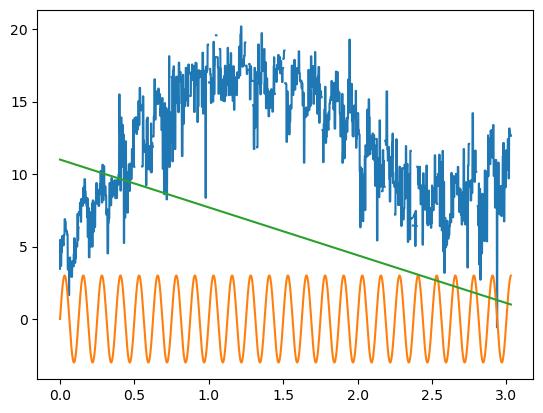

In [38]:
# simulate left_run

speed = 33  # cm/s
theta_period = 0.125  # seconds

t = np.arange(0, (b1.max() - b1.min()) / speed, 1e-3)
pos = np.linspace(b1.min(), b1.max(), t.size)
pos = np.flip(pos)


theta_phase = (2 * np.pi) * (t % theta_period) / theta_period

pos_ind = np.digitize(pos, b1) - 1
phase_ind = np.digitize(theta_phase, b2) - 1

sim_context = mid_left[pos_ind, phase_ind, :]


# fig, ax = plt.subplots
plt.plot(t, sim_context[:, 0])
plt.plot(t, np.sin(theta_phase) * 3)
plt.plot(t, pos / 10)

# plt.xlim(0, 1)
# plt.xlim(2,4)
# plt.xlim(6, 8)

## Sorted Spike response

In [170]:
from spyglass.common import interval_list_contains
from spyglass.common import interval_list_excludes

from src.c3po.analysis.analysis import bootstrap_traces

running = True
neuron_id = 12
spikes = spikes_list[neuron_id]
# spikes = spikes_list[8]
spikes = interval_list_contains(all_running_intervals, spikes)
# spikes = interval_list_excludes(running_intervals,spikes)

window = [-0.5, 1]
# window = [-0.1, 0.1]
# window = [-.02,.02]
response = analysis.alligned_response(spikes, window, pca=True)

yy, rng = bootstrap_traces(response, n_boot=30)

[10:59:43][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: interval_list_contains
	Use Interval.contains instead


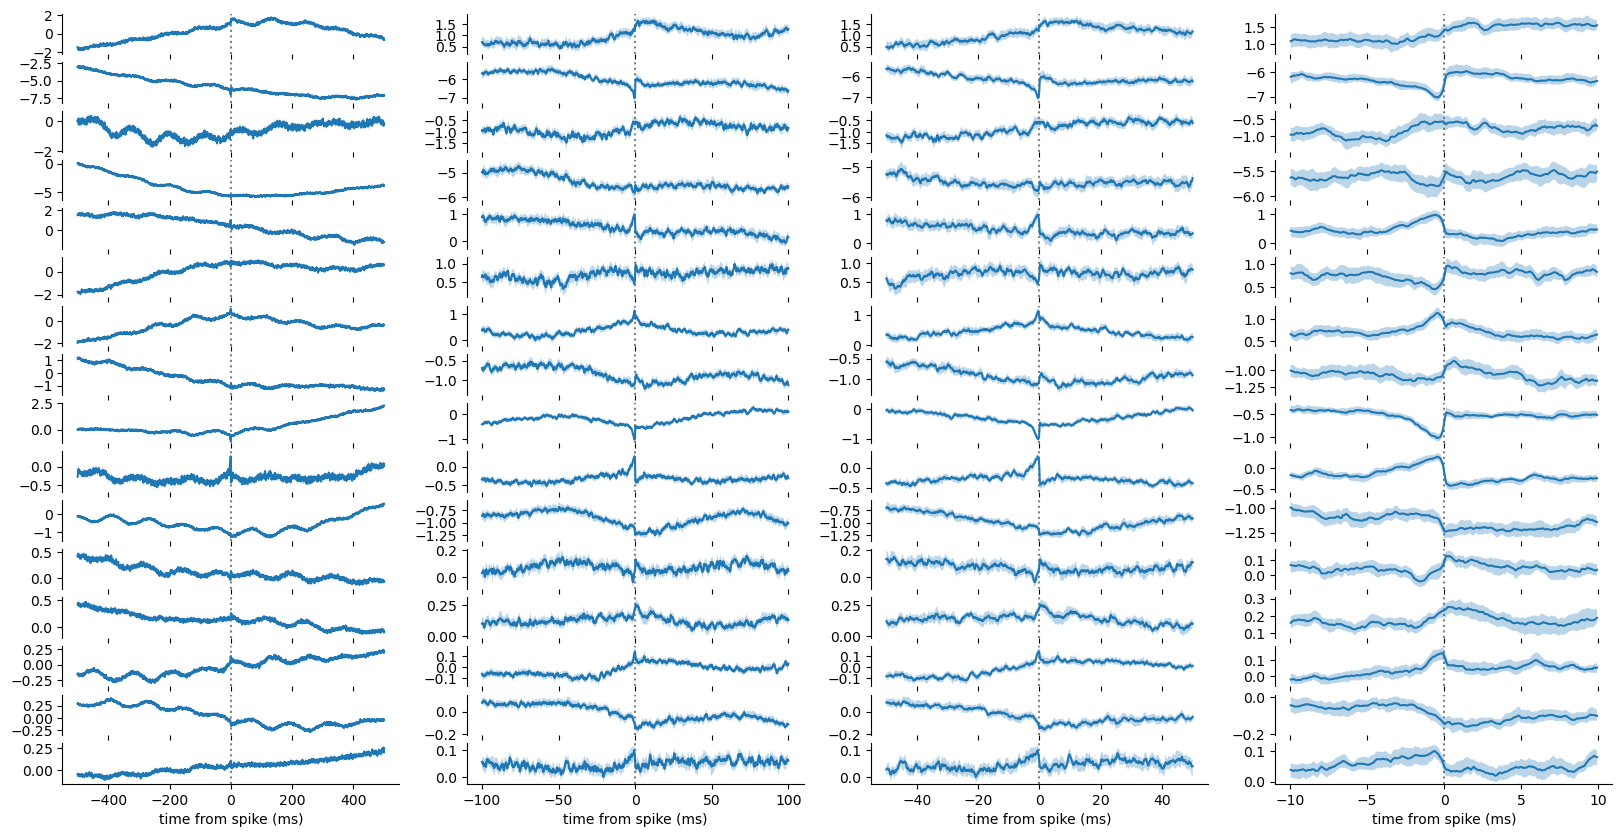

In [ ]:
plot_rng_list = [(-500, 500), (-100, 100), (-50, 50), (-10, 10)]
fig, ax_list = plt.subplots(
    nrows=min(context_dim, 16), ncols=len(plot_rng_list), sharex="col", figsize=(20, 10)
)


for p, plot_rng in enumerate(plot_rng_list):
    ax = ax_list[:, p]
    c = [plt.cm.twilight_shifted(phase / (2 * np.pi)) for phase in bins[1:]]
    t_plot = np.linspace(window[0], window[-1], response.shape[1]) * 1000
    ind_plot = np.logical_and(
        t_plot >= plot_rng[0],
        t_plot <= plot_rng[1],
    )
    t_plot = t_plot[ind_plot]
    for i, a in enumerate(ax):
        # a.plot(t_plot, np.mean(response[:, :, i], axis=0))
        a.plot(t_plot, yy[ind_plot, i])
        a.fill_between(t_plot, rng[0][ind_plot, i], rng[1][ind_plot, i], alpha=0.3)
        a.axvline(0, ls=":", c="grey", zorder=-1)
        # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5)
        a.spines[["top", "right", "bottom"]].set_visible(False)
    ax[-1].spines["bottom"].set_visible(True)
    ax[-1].set_xlabel("time from spike (ms)")

# fig.savefig(
#     f"{plot_folder}hpc_spike_response_{'running' if running else 'stationary'}_"
#     + f"neuron{neuron_id}_{int(window[0]*1000)}-{int(window[1]*1000)}ms.pdf",
# )

In [ ]:
x = 100 or 5
print(x)

100

## Position C vals binned by theta

In [ ]:
n_pos = 30
n_theta = 10

pca = False

# n_pos = 20
# n_theta = 15

# n_pos = 150
# n_theta = 75

left_binned_context, b1, b2, counts_left = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    phase_df.phase.values,
    phase_df.index,
    pca=pca,
    interpolated=True,
    valid_intervals=left_running_intervals,
    bins_1=np.linspace(10, 110, n_pos),
    bins_2=np.linspace(0.01, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)


right_binned_context, b1, b2, counts_right = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    phase_df.phase.values,
    phase_df.index,
    pca=pca,
    interpolated=True,
    valid_intervals=right_running_intervals,
    bins_1=np.linspace(10, 110, n_pos),
    bins_2=np.linspace(0.01, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)

/tmp/ipykernel_1496460/1813345577.py:7: RuntimeWarning: Mean of empty slice
  np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)


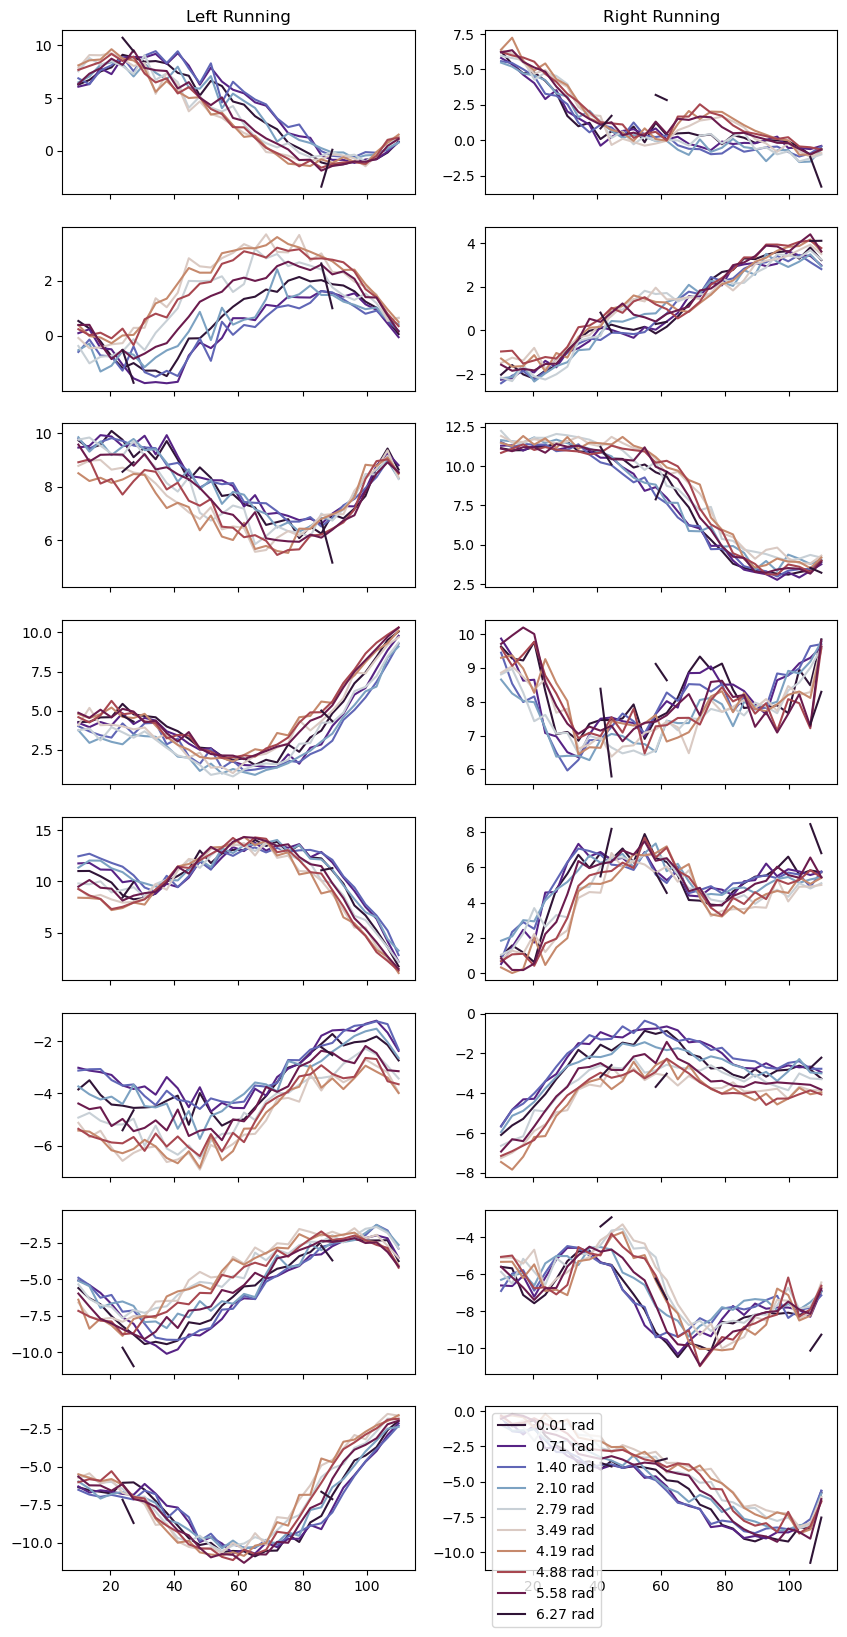

In [ ]:
fig, ax = plt.subplots(
    nrows=min(context_dim, 8), ncols=2, figsize=(10, 20), sharex=True
)

for i_context, binned_context in enumerate([left_binned_context, right_binned_context]):
    mid = np.array(
        [
            [
                np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(context_dim)
                for b in row
            ]
            for row in binned_context
        ]
    )

    for i_pc in range(ax.shape[0]):
        for i in range(mid.shape[1]):
            c_val = i / (mid.shape[1] - 1) if mid.shape[1] > 1 else 0
            color = plt.cm.twilight_shifted(c_val)
            y_val = mid[:, i, i_pc]
            # y_val = np.exp(y_val)
            label = f"{b2[i]:.2f} rad"
            ax[i_pc, i_context].plot(b1, y_val, color=color, label=label)

ax[0, 0].set_title("Left Running")
ax[0, 1].set_title("Right Running")
plt.legend()

In [38]:
mid.shape, b2.shape, i

((30, 5, 20), (5,), 4)

## Ripple Response

In [114]:
mark_id = "start_time"
ripple_intervals = ripple_df[["start_time", "end_time"]].values

analysis_ = analysis_ripples.copy()


mark_intervals = [r for r in ripple_intervals if r[1] - r[0] > 0.1]
mark_intervals = np.array(mark_intervals)

marks = mark_intervals[:, 0]

# marks = ripple_df[mark_id].values
# marks = ripple_df.end_time.values

window = [-0.5, 1]
# window = [-0.1, 0.1]
# window = [-0.02, 0.02]
# window = [0,.05]
response = analysis_.alligned_response(marks, window, pca=True)

yy, rng = bootstrap_traces(response, n_boot=30)

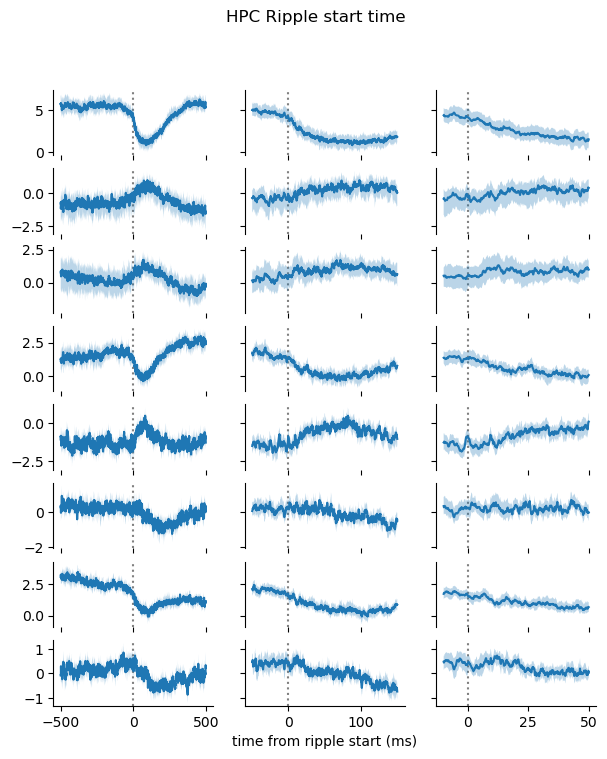

In [ ]:
plot_rng_list = [(-500, 500), (-50, 150), (-10, 50)]
fig, ax_list = plt.subplots(
    nrows=min(context_dim, 8),
    ncols=len(plot_rng_list),
    sharex="col",
    figsize=(7, 8),
    sharey="row",
)


for p, plot_rng in enumerate(plot_rng_list):
    ax = ax_list[:, p]
    c = [plt.cm.twilight_shifted(phase / (2 * np.pi)) for phase in bins[1:]]
    t_plot = np.linspace(window[0], window[-1], response.shape[1]) * 1000
    ind_plot = np.logical_and(
        t_plot >= plot_rng[0],
        t_plot <= plot_rng[1],
    )
    t_plot = t_plot[ind_plot]
    for i, a in enumerate(ax):
        # a.plot(t_plot, np.mean(response[:, :, i], axis=0))
        a.plot(t_plot, yy[ind_plot, i])
        a.fill_between(t_plot, rng[0][ind_plot, i], rng[1][ind_plot, i], alpha=0.3)
        a.axvline(0, ls=":", c="grey", zorder=-1)
        # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5)
        a.spines[["top", "right", "bottom"]].set_visible(False)
    ax[-1].spines["bottom"].set_visible(True)
ax_list[-1, 1].set_xlabel("time from ripple start (ms)")

fig.suptitle(f"HPC Ripple {mark_id.replace('_',' ')}")

fig.savefig(
    figure_folder / f"contextPCA_ripple_avg_response.svg",
)

In [116]:
ripple_intervals = ripple_df[["start_time", "end_time"]].values

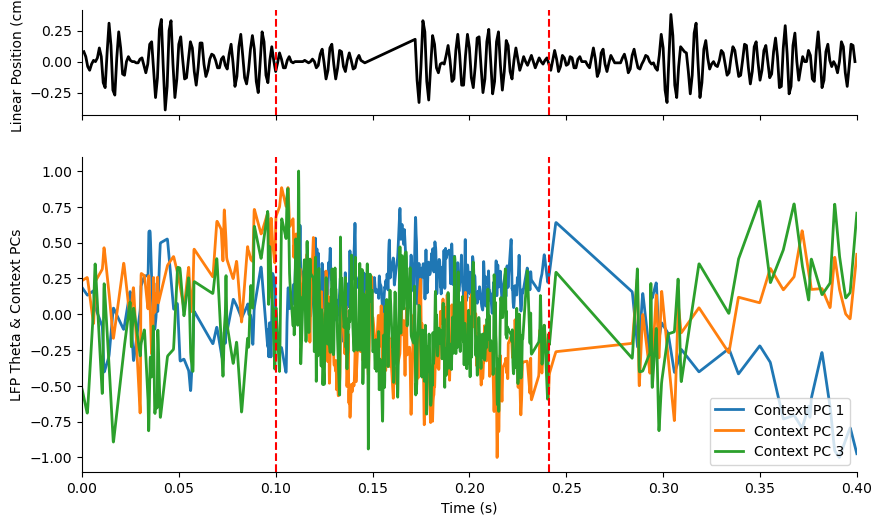

In [118]:
i = 4
t_rng = -0.1, 0.3


i = 43
t_rng = -1, 2
t_rng = -0.1, 0.3


pc_inds = np.array(
    [
        0,
        1,
        2,
    ]
)
# t_rng = 3,4

fig, ax = plt.subplots(
    nrows=2,
    sharex=True,
    height_ratios=[1, 3],
    figsize=(10, 6),
)

interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i]
st = interval[0] + t_rng[0]
en = interval[0] + t_rng[1]

t_ripple = ripple_band_obj.timestamps
ind_ripple = np.logical_and(
    t_ripple >= st,
    t_ripple <= en,
)
ax[0].plot(
    t_ripple[ind_ripple] - st,
    ripple_band_obj.data[ind_ripple][:, ref_ind] / 100,
    c="k",
    lw=2,
    zorder=-10,
    label="LFP Theta Band",
)

ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    plt.plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=2,
    )

ax[1].legend(loc="lower right")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position (cm)")
ax[1].set_ylabel("LFP Theta & Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])

# for t_ in interval:
#     ax[1].axvline(interval[0] - st, color="red", ls="--")

for ripple in ripple_intervals:
    # if ripple[0] > st and ripple[1] < en:
    #     for a in ax:
    #         a.axvline(ripple[0] - st, color="r", ls="--")
    #         a.axvline(ripple[1] - st, color="r", ls="--")
    for r in np.ravel(ripple):
        if r >= st and r <= en:
            for a in ax:
                a.axvline(r - st, color="r", ls="--")

# ax[0].fill_betweenx(
#     interval[0] - st,
#     interval[1] - st,
#     color="red",
#     alpha=0.3,
# )

In [ ]:
interval[0]

1663021525.3365562

## Behavior-alligned responses

### Licks

In [127]:
dio = "poke"
analysis = analysis_ripples.copy()

marks = behavior_evenets[dio]
marks = marks[np.logical_and(marks > analysis.t[0], marks < analysis.t[-1])]
response = analysis_.alligned_response(marks, window, pca=True)

yy, rng = bootstrap_traces(response, n_boot=100)

Text(0.5, 0.98, 'HPC poke')

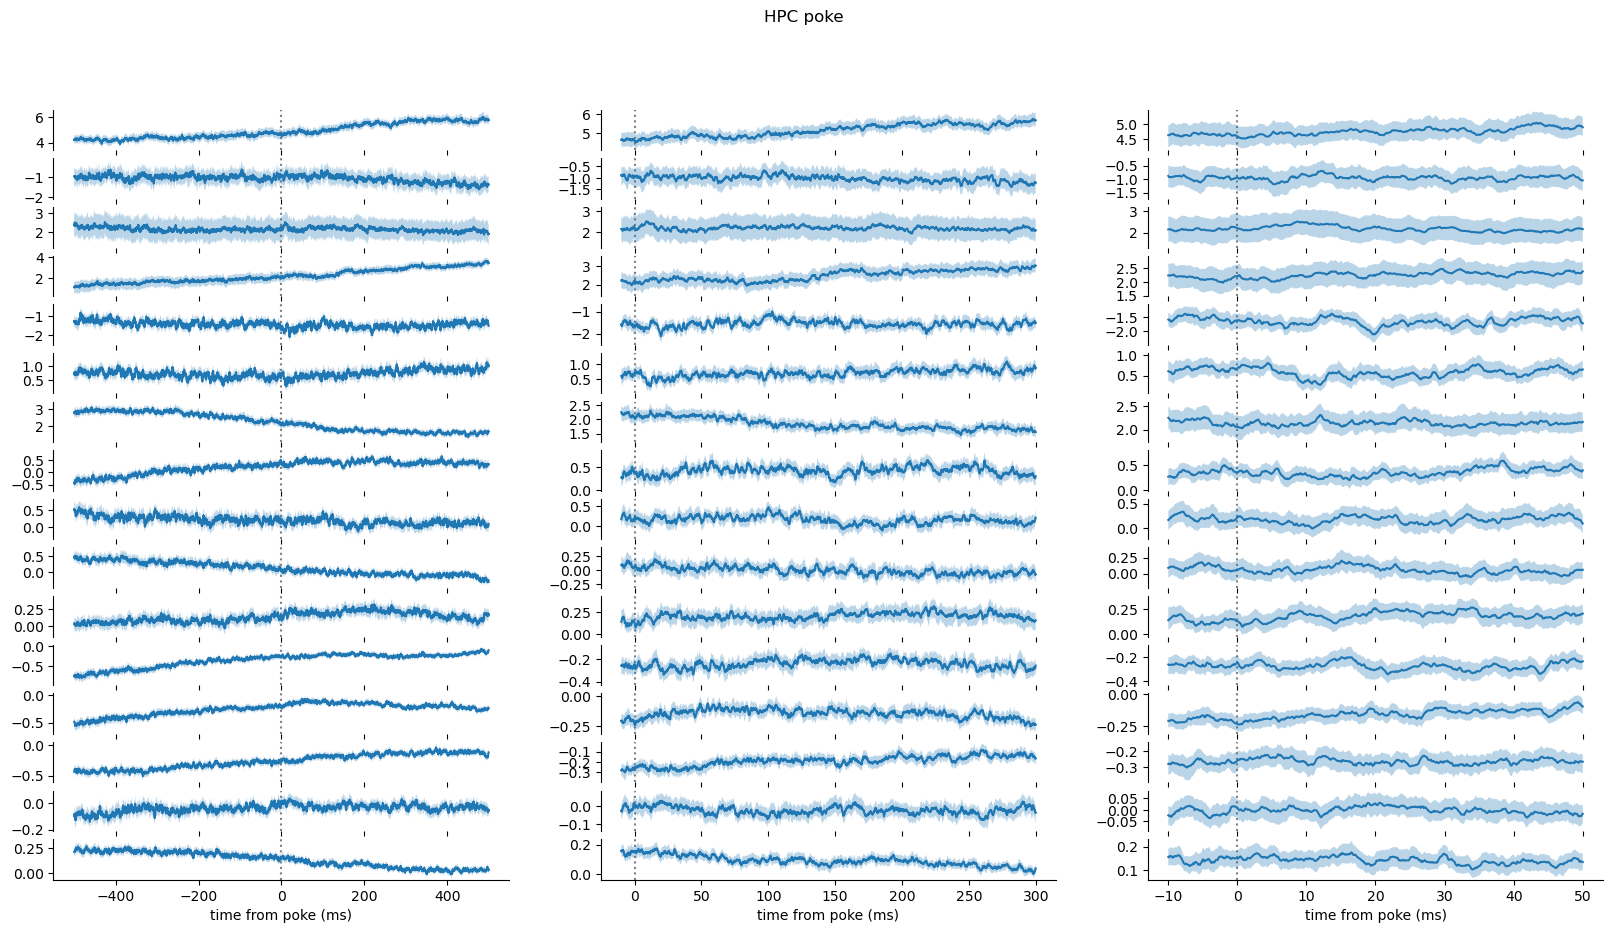

In [129]:
plot_rng_list = [(-500, 500), (-10, 300), (-10, 50)]
fig, ax_list = plt.subplots(
    nrows=min(context_dim, 16), ncols=len(plot_rng_list), sharex="col", figsize=(20, 10)
)


for p, plot_rng in enumerate(plot_rng_list):
    ax = ax_list[:, p]
    c = [plt.cm.twilight_shifted(phase / (2 * np.pi)) for phase in bins[1:]]
    t_plot = np.linspace(window[0], window[-1], response.shape[1]) * 1000
    ind_plot = np.logical_and(
        t_plot >= plot_rng[0],
        t_plot <= plot_rng[1],
    )
    t_plot = t_plot[ind_plot]
    for i, a in enumerate(ax):
        # a.plot(t_plot, np.mean(response[:, :, i], axis=0))
        a.plot(t_plot, yy[ind_plot, i])
        a.fill_between(t_plot, rng[0][ind_plot, i], rng[1][ind_plot, i], alpha=0.3)
        a.axvline(0, ls=":", c="grey", zorder=-1)
        # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5)
        a.spines[["top", "right", "bottom"]].set_visible(False)
    ax[-1].spines["bottom"].set_visible(True)
    ax[-1].set_xlabel("time from poke (ms)")

fig.suptitle(f"HPC {dio}")

### Rewards

In [73]:
dio = "reward"
marks = behavior_evenets[dio]
marks = marks[np.logical_and(marks > analysis.t[0], marks < analysis.t[-1])]
response = analysis.alligned_response(marks, window, pca=True)

yy, rng = bootstrap_traces(response, n_boot=100)

Text(0.5, 1.0, 'HPC reward event')

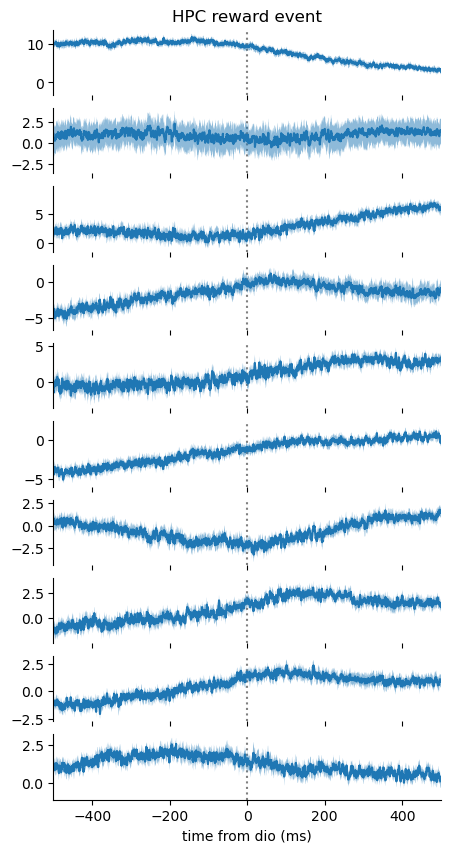

In [74]:
fig, ax = plt.subplots(nrows=min(context_dim, 10), sharex=True, figsize=(5, 10))

c = [plt.cm.twilight_shifted(phase / (2 * np.pi)) for phase in bins[1:]]
t_plot = np.linspace(window[0], window[-1], response.shape[1]) * 1000
for i, a in enumerate(ax):
    # a.plot(t_plot, np.mean(response[:, :, i], axis=0))
    a.plot(t_plot, yy[:, i])
    a.fill_between(
        t_plot,
        rng[0][:, i],
        rng[1][:, i],
        alpha=0.5,
        # facecolor=c[0],
    )

    a.axvline(0, ls=":", c="grey", zorder=-1)
    # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5)
    a.spines[["top", "right", "bottom"]].set_visible(False)
ax[-1].spines["bottom"].set_visible(True)
plt.xlim(-500, 500)
plt.xlabel("time from dio (ms)")
ax[0].set_title(f"HPC {dio} event")

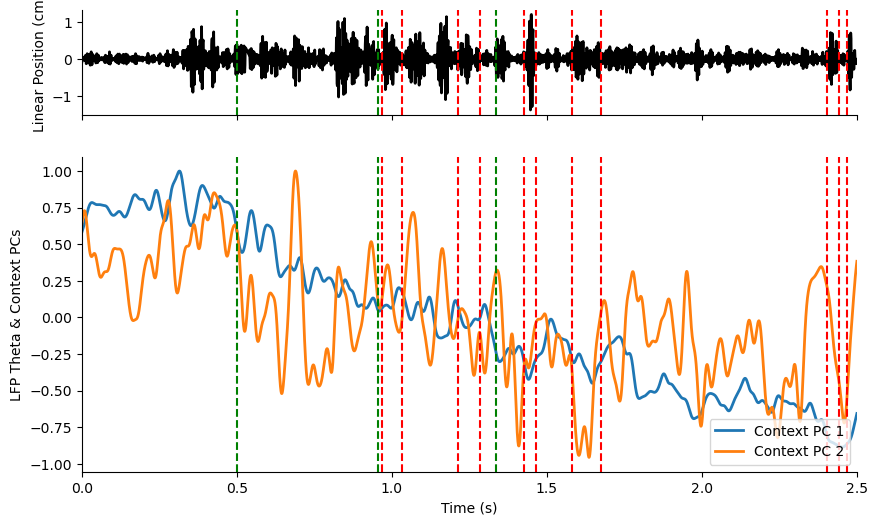

In [75]:
i = 8
t_rng = -0.5, 2
smooth = 31


pc_inds = np.array(
    [
        0,
        1,
    ]
)
# t_rng = 3,4

fig, ax = plt.subplots(
    nrows=2,
    sharex=True,
    height_ratios=[1, 3],
    figsize=(10, 6),
)


st = marks[i] + t_rng[0]
en = marks[i] + t_rng[1]

t_ripple = ripple_band_obj.timestamps
ind_ripple = np.logical_and(
    t_ripple >= st,
    t_ripple <= en,
)
ax[0].plot(
    t_ripple[ind_ripple] - st,
    ripple_band_obj.data[ind_ripple][:, ref_ind] / 100,
    c="k",
    lw=2,
    zorder=-10,
    label="LFP Theta Band",
)

ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, smooth, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    plt.plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=2,
    )

ax[1].legend(loc="lower right")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position (cm)")
ax[1].set_ylabel("LFP Theta & Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])

# for t_ in interval:
#     ax[1].axvline(interval[0] - st, color="red", ls="--")

for ripple in ripple_intervals:
    # if ripple[0] > st and ripple[1] < en:
    #     for a in ax:
    #         a.axvline(ripple[0] - st, color="r", ls="--")
    #         a.axvline(ripple[1] - st, color="r", ls="--")
    for r in np.ravel(ripple):
        if r >= st and r <= en:
            for a in ax:
                a.axvline(r - st, color="r", ls="--")

for poke in behavior_evenets["poke"]:
    if poke >= st and poke <= en:
        for a in ax:
            a.axvline(poke - st, color="g", ls="--")

# ax[0].fill_betweenx(
#     interval[0] - st,
#     interval[1] - st,
#     color="red",
#     alpha=0.3,
# )

# Decoder

In [32]:
pred_interval = [analysis.t[0] + 42, analysis.t[0] + 46]


i_pred = 5
interval = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
pred_interval = interval[i_pred]

In [33]:
t_feature = pos_df.index.values
feature = pos_df.linear_position.values[:, None]


# analysis.initialize_decoder(
#     "discretized_regression",
#     n_bins=100,
#     max_iter=1000,
#     balance_groups=True,
#     multidim=False,
# )

analysis.initialize_decoder(
    "knn",
    n_neighbors=30,
    weights="distance",
)


fit_intervals = all_running_intervals

fit_intervals = [x for x in all_running_intervals if x[0] > pred_interval[1]]

analysis.fit_decoder(
    feature,
    t_feature,
    intervals=fit_intervals,
    pca=True,
    # decode_dim=slice(1, 2),
    interpolate=True,
    # interpolate=True,
    # smooth_context=30,
)

In [ ]:
t_pred, pos_pred = analysis.predict_decoder(
    pred_interval, interpolate=True, smooth_context=100
)

KeyboardInterrupt: 

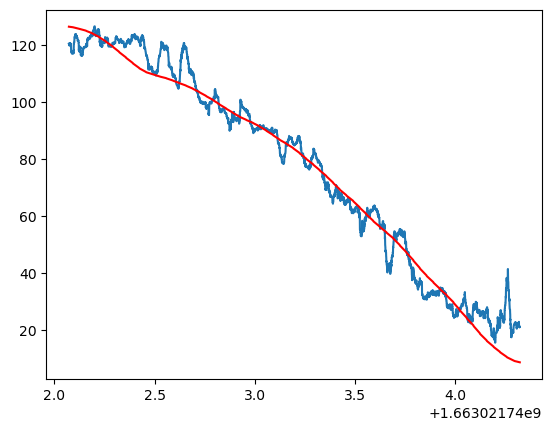

In [298]:
plt.plot(t_pred, pos_pred)

ind_pos = np.logical_and(
    pos_df.index >= pred_interval[0],
    pos_df.index <= pred_interval[1],
)
plt.plot(
    pos_df.index[ind_pos],
    pos_df.linear_position[ind_pos],
    c="r",
    # s=10,
)

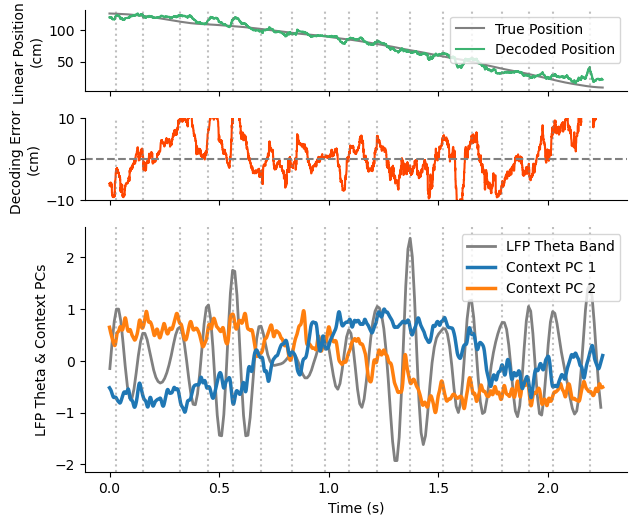

In [ ]:
analysis = analysis_all

interval = pred_interval
st = interval[0]
en = interval[1]


fig, ax = plt.subplots(
    nrows=3,
    sharex=True,
    height_ratios=[1, 1, 3],
    figsize=(7, 6),
)
t_theta = theta_band_obj.timestamps
ind_theta = np.logical_and(
    t_theta >= st,
    t_theta <= en,
)

t_lfp = t_theta[ind_theta] - st
lfp_plot = theta_band_obj.data[ind_theta][:, ref_ind] / 100
plt.plot(
    t_theta[ind_theta] - st,
    theta_band_obj.data[ind_theta][:, ref_ind] / 100,
    c="grey",
    lw=2,
    zorder=-10,
    label="LFP Theta Band",
)

ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, smooth_width, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(2):
    plt.plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=1 - j,
        label=f"Context PC {j+1}",
        lw=2.5,
    )
    # break


pos_ind = np.logical_and(
    pos_df.index >= st,
    pos_df.index <= en,
)
t_pos = pos_df.index[pos_ind] - st
pos_plot = pos_df.linear_position[pos_ind]
ax[0].plot(
    t_pos,
    pos_plot,
    c="gray",
    # s=5,
    zorder=-5,
    label="True Position",
)
ax[0].plot(
    t_pred - st,
    pos_pred,
    c="mediumseagreen",
    # lw=1,
    label="Decoded Position",
    zorder=-1,
)

pos_upsampled = np.interp(
    t_pred - st,
    t_pos,
    pos_plot,
)
ax[1].plot(t_pred - st, pos_pred[:, 0] - pos_upsampled, color="orangered")
ax[1].axhline(0, ls="--", c="grey")
ax[1].set_ylim(-10, 10)

ax[-1].legend(loc="upper right")
ax[0].legend(loc="upper right")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[-1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position \n(cm)")
ax[-1].set_ylabel("LFP Theta & Context PCs")
ax[1].set_ylabel("Decoding Error \n(cm)")

d_lfp = np.diff(lfp_plot)
upward = (d_lfp > 0).astype(int)
peaks = np.where(np.diff(upward) == -1)[0] + 1
peaks = t_lfp[peaks]
for a in ax:
    for p in peaks:
        if p >= 0 and p <= (en - st):
            a.axvline(p, color="grey", ls=":", alpha=0.5)

fig.savefig(
    figure_folder / f"example_decode_and_precessions_traces.svg",
)

## Ripple_decode

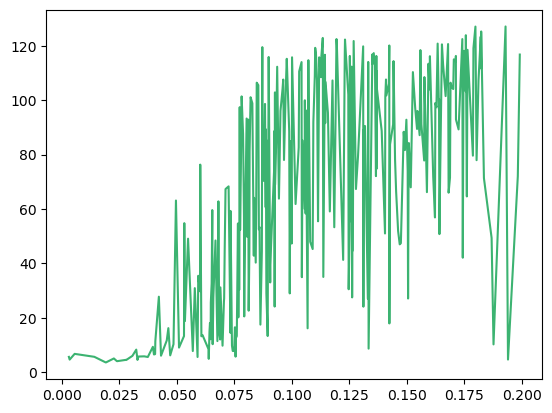

In [36]:
i = 4
t_rng = -0.05, 0.15


# i = 43
# t_rng = -1, 2
# t_rng = -0.05, 0.3


pc_inds = np.array(
    [
        0,
        1,
        2,
    ]
)
# t_rng = 3,4


interval = [i_ for i_ in ripple_intervals if i_[1] - i_[0] > 0.1]
interval = interval[i]
ripple_interval_i = interval.copy()
st = interval[0] + t_rng[0]
en = interval[0] + t_rng[1]

pred_t, pos_pred = analysis.predict_decoder([st, en], interpolate=False)
plt.plot(pred_t - st, pos_pred, c="mediumseagreen", label="Decoded Position")

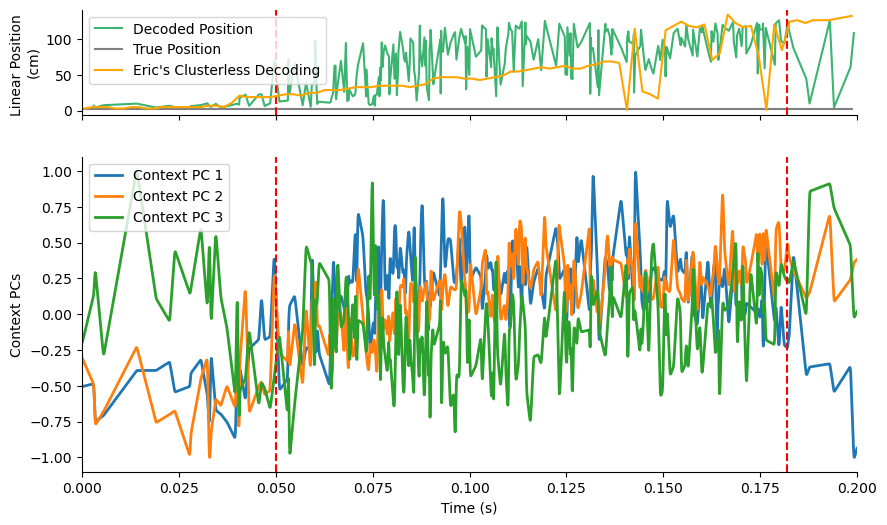

In [374]:
fig, ax = plt.subplots(
    nrows=2,
    sharex=True,
    height_ratios=[1, 3],
    figsize=(10, 6),
)

t_ripple = ripple_band_obj.timestamps
ind_ripple = np.logical_and(
    t_ripple >= st,
    t_ripple <= en,
)
# ax[0].plot(
#     t_ripple[ind_ripple] - st,
#     ripple_band_obj.data[ind_ripple][:, ref_ind] / 100,
#     c="k",
#     lw=2,
#     zorder=-10,
#     label="LFP Theta Band",
# )
ax[0].plot(pred_t - st, pos_pred, c="mediumseagreen", label="Decoded Position")


pos_t = pos_df.index.values
ind_pos = np.logical_and(
    pos_t >= st,
    pos_t <= en,
)
ax[0].plot(
    pos_t[ind_pos] - st,
    pos_df.linear_position[ind_pos],
    c="grey",
    # s=10,
    label="True Position",
)


ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, 1, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(c_plot.shape[1]):
    plt.plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=-1,
        label=f"Context PC {j+1}",
        lw=2,
    )


for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position \n(cm)")
ax[1].set_ylabel("Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])

# for t_ in interval:
#     ax[1].axvline(interval[0] - st, color="red", ls="--")

for ripple in ripple_intervals:
    # if ripple[0] > st and ripple[1] < en:
    #     for a in ax:
    #         a.axvline(ripple[0] - st, color="r", ls="--")
    #         a.axvline(ripple[1] - st, color="r", ls="--")
    for r in np.ravel(ripple):
        if r >= st and r <= en:
            for a in ax:
                a.axvline(r - st, color="r", ls="--")


ind_decode = np.logical_and(
    decode_time >= st,
    decode_time <= en,
)
ax[0].plot(
    decode_time[ind_decode] - st,
    decode_pos[ind_decode],
    c="orange",
    label="Eric's Clusterless Decoding",
)

ax[0].legend(loc="upper left")
ax[1].legend(loc="upper left")

fig.savefig(
    figure_folder / f"example_ripple_decode_and_model_comparison.svg",
)

In [ ]:
lags, corr = analysis_.cross_correlation(
    intervals=np.array([ripple_interval_i]),
    pca=True,
    max_lag_seconds=0.05,
    dim_limit=10,
    # processes=20,
)

100%|██████████| 10/10 [00:00<00:00, 50.82it/s]


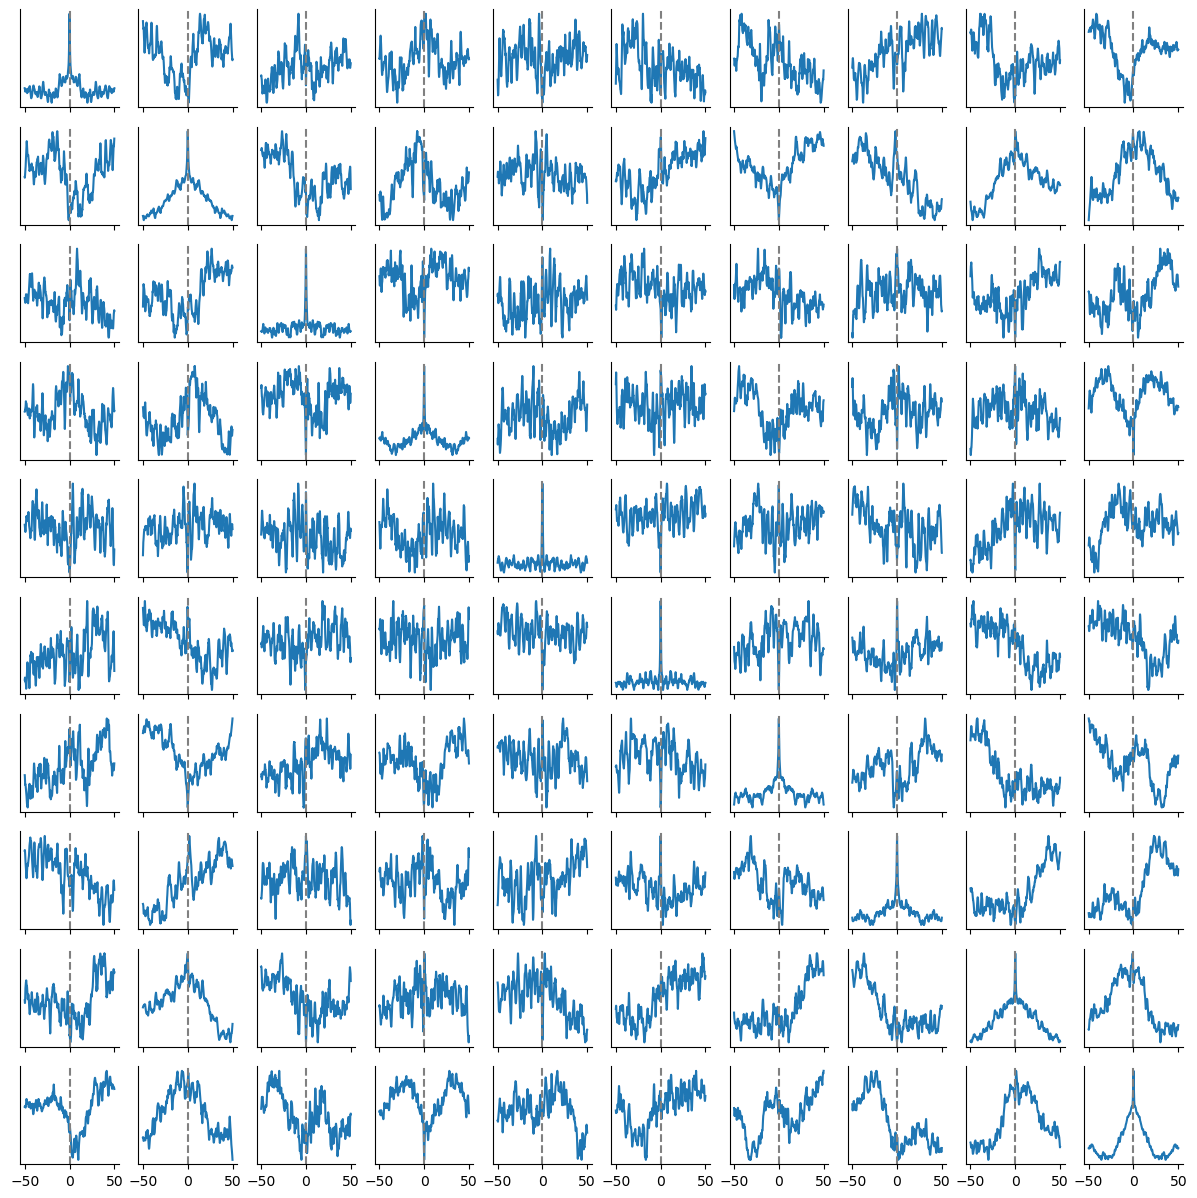

In [ ]:
n_plot = min(10, corr.shape[0])
fig, ax = plt.subplots(
    nrows=n_plot, ncols=n_plot, sharex=True, figsize=(1.5 * n_plot, 1.5 * n_plot)
)
for i in range(n_plot):
    for j in range(n_plot):
        ax[i, j].plot(lags * 1000, corr[i, j])
        ax[i, j].axvline(0, color="grey", ls="--")
        ax[i, j].spines[["top", "right"]].set_visible(False)
        ax[i, j].set_yticks([])

In [384]:
np.diff(analysis.t_interp[:10])

array([9.98973846e-05, 9.98973846e-05, 9.98973846e-05, 9.98973846e-05,
       9.98973846e-05, 9.98973846e-05, 9.98973846e-05, 9.98973846e-05,
       9.98973846e-05])

In [37]:
response = analysis_.alligned_response(
    ripple_interval_i[0], t_plot=[-0.1, 0.3], pca=True, smooth_context=100
)

(-50.0, 200.0)

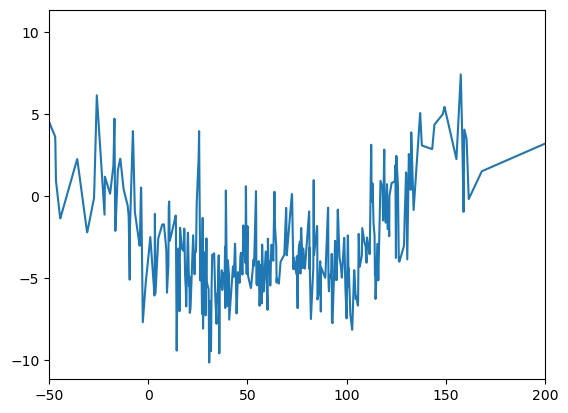

In [41]:
tplot = np.linspace(-0.1, 0.3, response.shape[1]) * 1000

plt.plot(tplot, response[0, :, :1])
plt.xlim(-50, 200)

# load decode data

In [ ]:
from spyglass.decoding.v1.clusterless import ClusterlessDecodingV1

decode_query = (
    ClusterlessDecodingV1() & key & {"encoding_interval": "pos 9 valid times"}
)

results = decode_query.fetch_results()
posterior = results.causal_posterior.unstack("state_bins").sum("state")[0]
decode_pos = posterior.idxmax("position").values
decode_time = results.time.values

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  warnings.warn(
/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/xarray/namedarray/core.py:496: UserWarning: Duplicate dimension names present: dimensions {'states'} appear more than once in dims=('states', 'states'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct

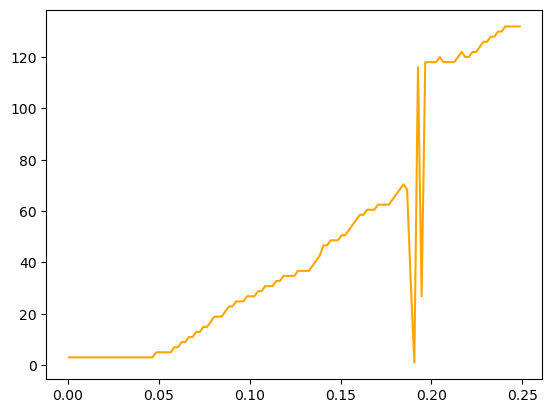